Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Segment shape: (106944, 32)


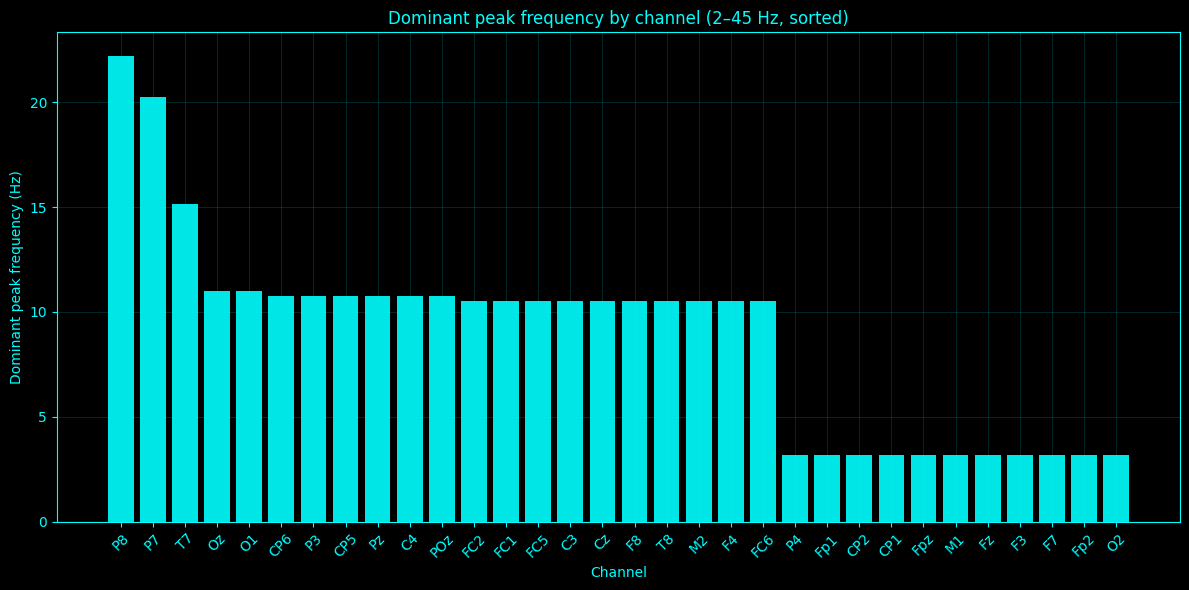

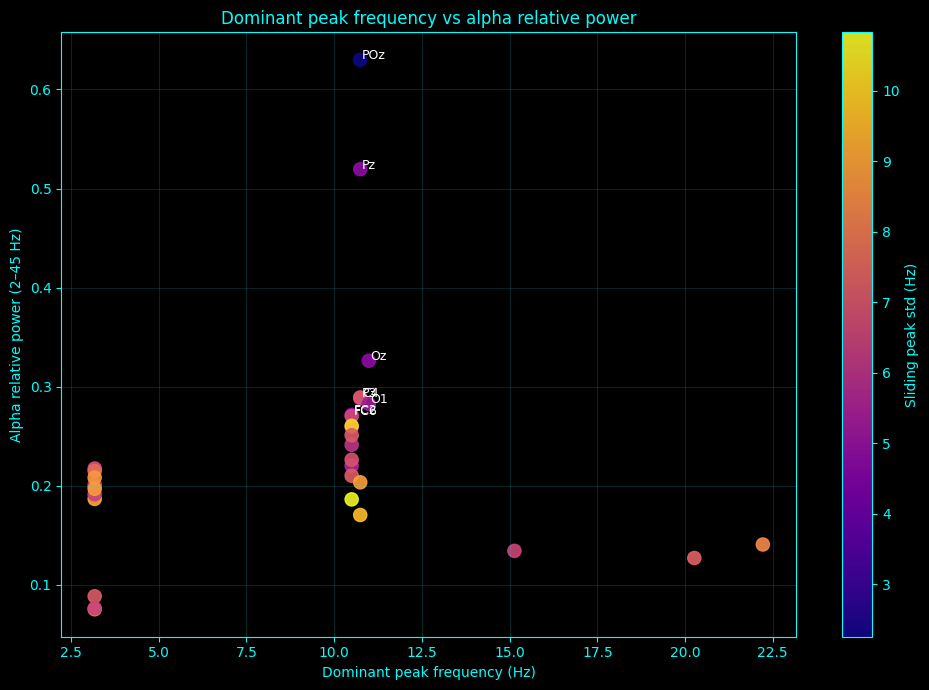

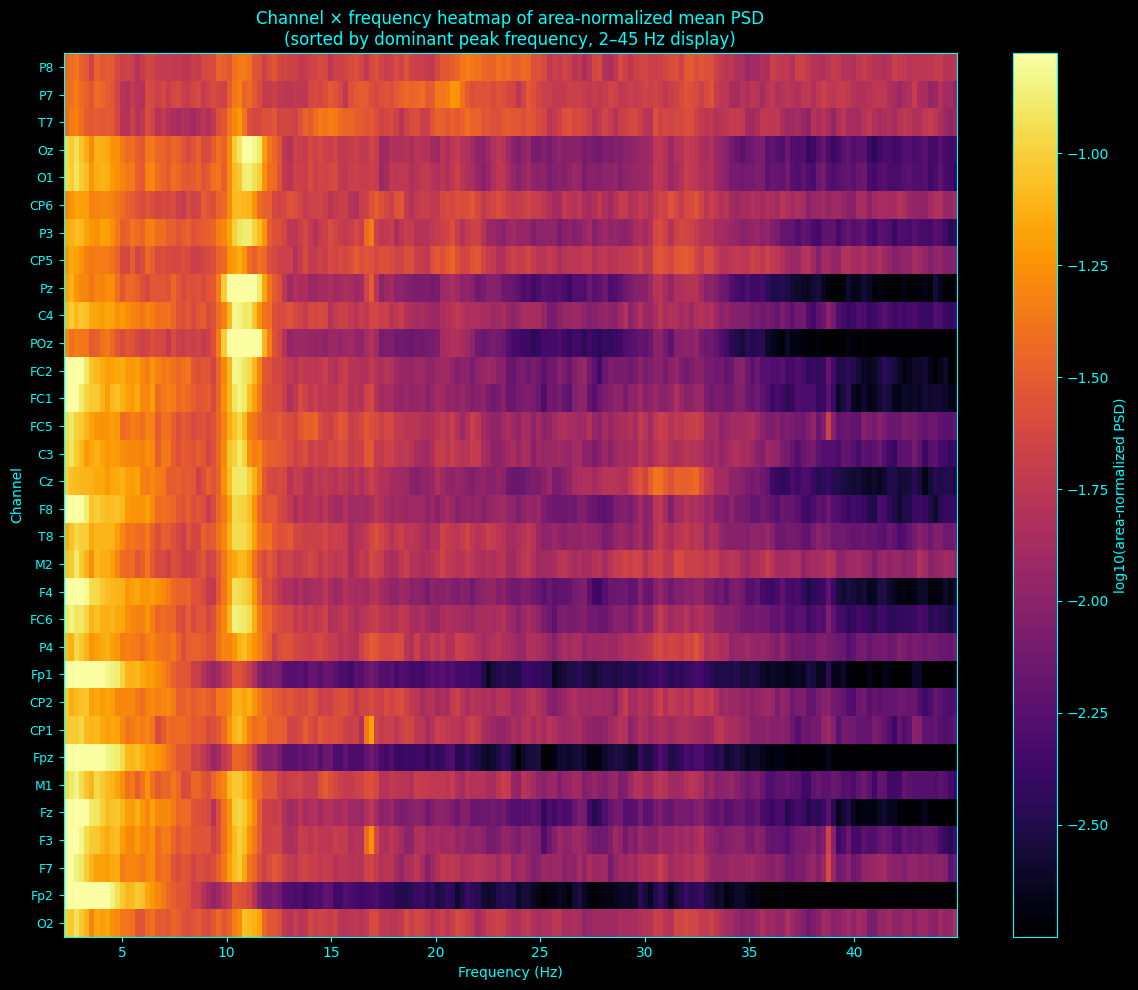

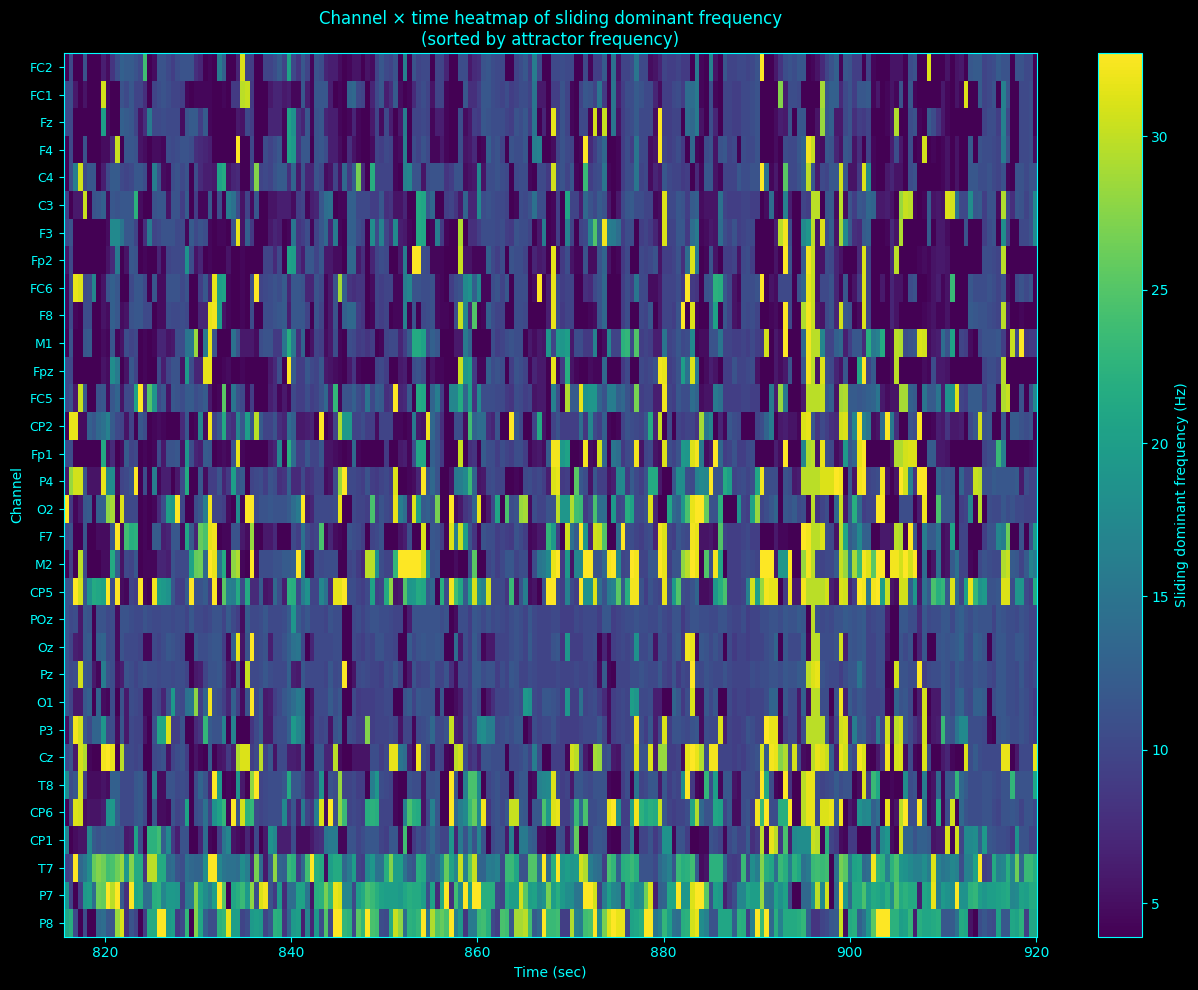

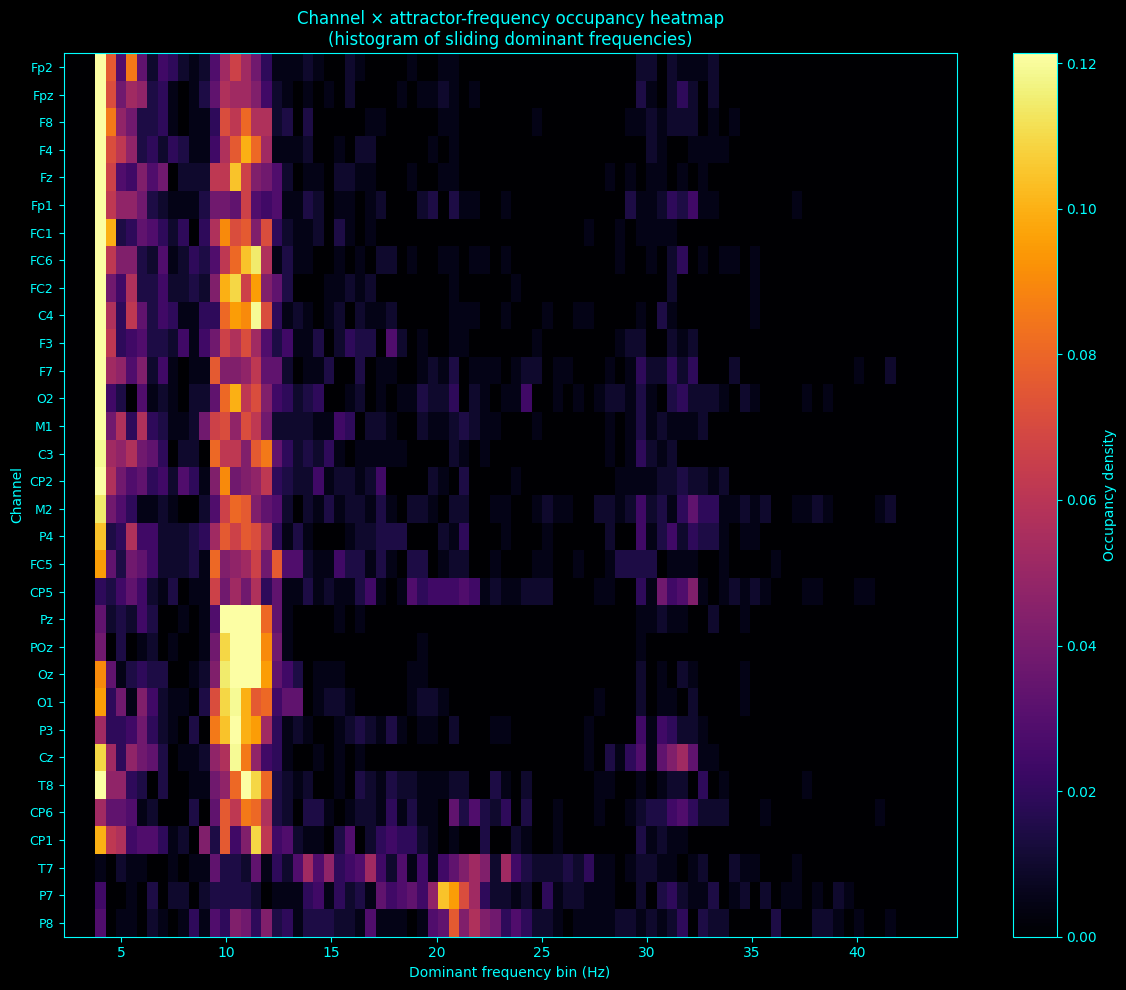

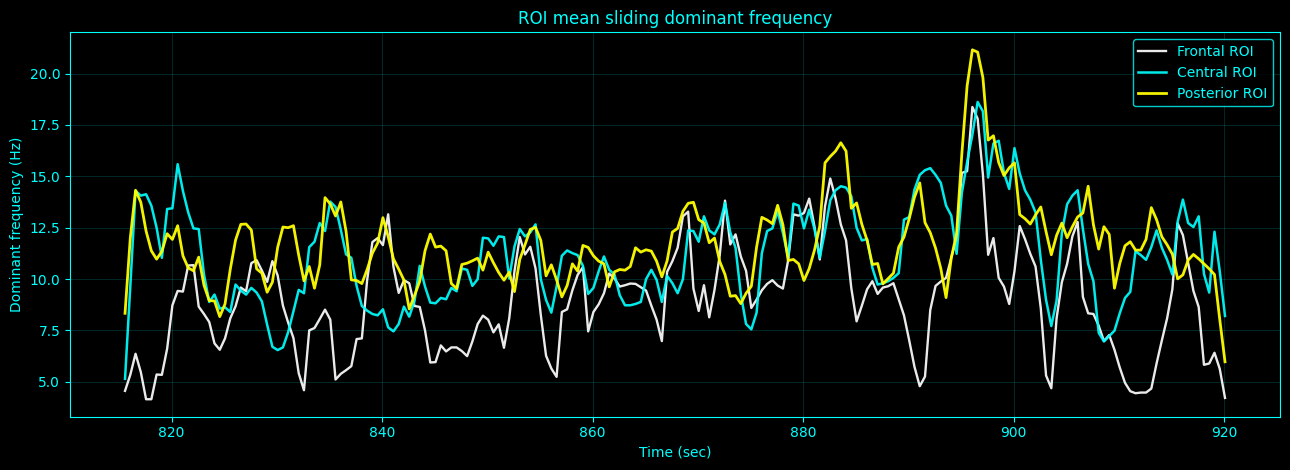

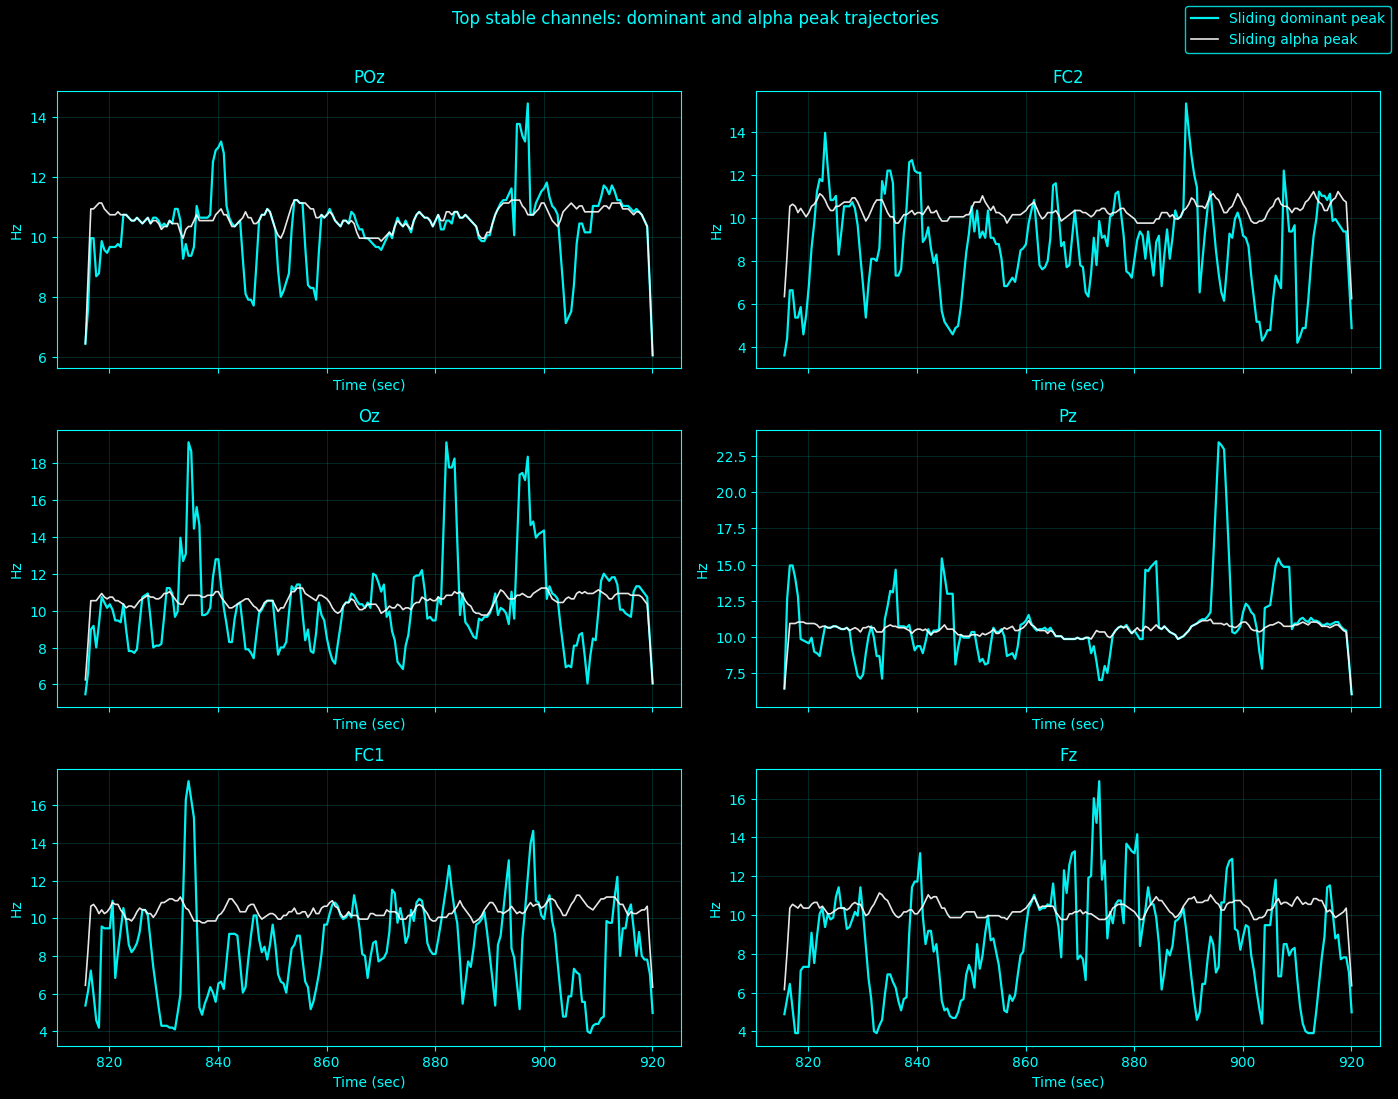


Saved dict NPY: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_peak_frequency_atlas/PeakFrequencies_x.npy
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_peak_frequency_atlas/exploratory_peak_frequency_atlas_outputs.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_peak_frequency_atlas/peak_frequency_channel_summary.csv
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_peak_frequency_atlas/exploratory_peak_frequency_atlas_notes.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_peak_frequency_atlas/plots
Done.


In [2]:

# ---- Shared runtime mode (full preserves this cell's original settings) ----
FAST_OPTION = globals().get("FAST_OPTION", "full")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: full, balanced, fast, ultra")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — aligned to the upgraded scripts
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_peak_frequency_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

analysis_band = (2.0, 45.0)
display_band = (2.0, 45.0)
alpha_band = (8.0, 13.0)
theta_band = (4.0, 8.0)
beta_band = (13.0, 30.0)
delta_band = (2.0, 4.0)
low_gamma_band = (30.0, 45.0)

band_defs = {
    "delta": delta_band,
    "theta": theta_band,
    "alpha": alpha_band,
    "beta": beta_band,
    "low_gamma": low_gamma_band,
}
band_names = list(band_defs.keys())

# Welch settings
welch_window_sec = 4.0
welch_overlap = 0.50
welch_nfft = 4096
detrend_mode = "constant"
apply_common_average_reference = False

# Sliding spectral-peak settings
sliding_window_sec = 2.0
sliding_step_sec = {"full": 0.5, "balanced": 0.75, "fast": 1, "ultra": 1.5}[FAST_OPTION]
sliding_nfft = 2048

# Frequency attractor histogram
peak_hist_bin_width_hz = 0.5

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4'],
    "central":   ['C3', 'Cz', 'C4'],
    "posterior": ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2'],
}

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def band_mask(freqs_hz, band):
    lo, hi = band
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def zscore_1d(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    return (x - mu) / (sd + eps)

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def welch_psd(y, fs, window_sec=4.0, overlap=0.5, detrend="constant", nfft=None):
    nperseg = min(int(round(window_sec * fs)), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = min(int(round(overlap * nperseg)), nperseg - 1)

    freqs_hz, pxx = signal.welch(
        y,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        scaling="density",
        nfft=nfft,
    )
    return freqs_hz, pxx

def area_normalize_1d(freqs_hz, x, band):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = band_mask(freqs_hz, band) & np.isfinite(x) & (x >= 0)
    if np.sum(mask) < 2:
        return out

    area = integrate_trapezoid(x[mask], freqs_hz[mask])
    if not np.isfinite(area) or area <= 0:
        return out

    out[mask] = x[mask] / area
    return out

def integrate_band_1d(freqs_hz, x, band):
    mask = band_mask(freqs_hz, band) & np.isfinite(x)
    if np.sum(mask) < 2:
        return np.nan
    return float(integrate_trapezoid(x[mask], freqs_hz[mask]))

def spectral_entropy_from_psd(freqs_hz, pxx, band=(2.0, 45.0), normalize=True):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)

    area = integrate_trapezoid(p, f)
    if not np.isfinite(area) or area <= 0:
        return np.nan, np.nan

    p = p / area
    p = p / (np.sum(p) + eps)

    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    Hn = H / (Hmax + eps) if normalize else H
    return float(H), float(Hn)

def spectral_centroid_from_psd(freqs_hz, pxx, band=(2.0, 45.0)):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan
    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)
    s = np.sum(p)
    if s <= 0:
        return np.nan
    return float(np.sum(f * p) / (s + eps))

def dominant_peak_with_fallback(freqs_hz, spectrum_1d, band=(2.0, 45.0), smooth_win=9):
    """
    Returns a robust dominant frequency estimate.
    First tries to find a real local peak with nontrivial prominence.
    If none exists, falls back to the maximum of the smoothed spectrum in-band.
    """
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 5:
        return np.nan, np.nan, np.nan, np.nan, False

    f = freqs_hz[mask]
    y = smooth_1d(spectrum_1d[mask], win=smooth_win)

    peaks, _ = signal.find_peaks(y)
    if len(peaks) > 0:
        prominences = signal.peak_prominences(y, peaks)[0]
        valid = (peaks > 0) & (peaks < len(y) - 1)
        if np.any(valid):
            peaks = peaks[valid]
            prominences = prominences[valid]

            min_prominence = max(0.05 * np.nanmax(y), 1.5 * np.nanmedian(np.abs(np.diff(y))))
            strong = prominences >= min_prominence
            if np.any(strong):
                peaks = peaks[strong]
                prominences = prominences[strong]
                winner = int(np.argmax(prominences))
                peak_idx = peaks[winner]

                peak_freq = float(f[peak_idx])
                peak_height = float(y[peak_idx])
                peak_prominence = float(prominences[winner])
                peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
                return peak_freq, peak_height, peak_prominence, peak_contrast, True

    # Fallback: smooth in-band argmax
    idx = int(np.nanargmax(y))
    peak_freq = float(f[idx])
    peak_height = float(y[idx])
    peak_prominence = np.nan
    peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
    return peak_freq, peak_height, peak_prominence, peak_contrast, False

def classify_dominant_band(freqs_hz, pxx_norm, band_defs):
    band_values = {}
    for band_name, band in band_defs.items():
        band_values[band_name] = integrate_band_1d(freqs_hz, pxx_norm, band)

    if not np.any(np.isfinite(list(band_values.values()))):
        return "unknown", band_values

    best_band = max(band_values, key=lambda k: (-np.inf if not np.isfinite(band_values[k]) else band_values[k]))
    return best_band, band_values

def sliding_peak_dynamics(y, fs, analysis_band=(2.0, 45.0), alpha_band=(8.0, 13.0),
                          band_defs=None, window_sec=2.0, step_sec=0.5, detrend="constant", nfft=2048):
    win = max(int(round(window_sec * fs)), 256)
    step = max(int(round(step_sec * fs)), 1)

    centers_sec = []
    dominant_peak_series = []
    alpha_peak_series = []
    dominant_band_series = []
    is_local_peak_series = []
    centroid_series = []
    entropy_series = []

    for start in range(0, len(y) - win + 1, step):
        stop = start + win
        chunk = y[start:stop]

        freqs_hz, pxx = welch_psd(
            chunk,
            fs=fs,
            window_sec=min(window_sec, len(chunk) / fs),
            overlap=0.5,
            detrend=detrend,
            nfft=nfft,
        )

        pxx_norm = area_normalize_1d(freqs_hz, pxx, analysis_band)

        dom_peak, _, _, _, is_local = dominant_peak_with_fallback(
            freqs_hz,
            pxx_norm,
            band=analysis_band,
            smooth_win=7,
        )
        alpha_peak, _, _, _, _ = dominant_peak_with_fallback(
            freqs_hz,
            pxx_norm,
            band=alpha_band,
            smooth_win=7,
        )
        dom_band, _ = classify_dominant_band(freqs_hz, pxx_norm, band_defs)
        centroid = spectral_centroid_from_psd(freqs_hz, pxx, band=analysis_band)
        _, Hn = spectral_entropy_from_psd(freqs_hz, pxx, band=analysis_band, normalize=True)

        centers_sec.append((start + stop) / 2.0 / fs)
        dominant_peak_series.append(dom_peak)
        alpha_peak_series.append(alpha_peak)
        dominant_band_series.append(dom_band)
        is_local_peak_series.append(bool(is_local))
        centroid_series.append(centroid)
        entropy_series.append(Hn)

    return {
        "time_sec_rel": np.asarray(centers_sec),
        "dominant_peak_frequency_Hz": np.asarray(dominant_peak_series),
        "alpha_peak_frequency_Hz": np.asarray(alpha_peak_series),
        "dominant_band": np.asarray(dominant_band_series, dtype=object),
        "is_local_peak": np.asarray(is_local_peak_series, dtype=bool),
        "spectral_centroid_Hz": np.asarray(centroid_series),
        "spectral_entropy_normalized": np.asarray(entropy_series),
    }

def peak_frequency_histogram(peak_series_hz, band=(2.0, 45.0), bin_width_hz=0.5):
    valid = np.asarray(peak_series_hz, dtype=float)
    valid = valid[np.isfinite(valid)]
    valid = valid[(valid >= band[0]) & (valid <= band[1])]

    bins = np.arange(band[0], band[1] + bin_width_hz, bin_width_hz)
    if len(valid) == 0:
        hist = np.zeros(len(bins) - 1, dtype=float)
    else:
        hist, _ = np.histogram(valid, bins=bins)
        hist = hist.astype(float)
        hist = hist / (np.sum(hist) + eps)

    centers = 0.5 * (bins[:-1] + bins[1:])
    return centers, hist

def normalized_hist_entropy(hist):
    hist = np.asarray(hist, dtype=float)
    hist = hist[hist > 0]
    if len(hist) == 0:
        return np.nan
    H = -np.sum(hist * np.log(hist + eps))
    Hmax = np.log(len(hist) + eps)
    return float(H / (Hmax + eps))

def band_transition_rate(band_series):
    if len(band_series) < 2:
        return np.nan
    changes = 0
    valid_steps = 0
    for a, b in zip(band_series[:-1], band_series[1:]):
        if a == "unknown" or b == "unknown":
            continue
        valid_steps += 1
        if a != b:
            changes += 1
    if valid_steps == 0:
        return np.nan
    return float(changes / valid_steps)

def roi_average_matrix(matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.full(matrix.shape[0], np.nan)
    return np.nanmean(matrix[:, idx], axis=1)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Segment shape: {segment.shape}")

# -------------------------------------------------------
# CORE ANALYSIS
# -------------------------------------------------------
peak_frequency_dict = {}

summary_rows = []
mean_psd_matrix = []
sliding_peak_matrix = []
sliding_alpha_peak_matrix = []
sliding_centroid_matrix = []
sliding_entropy_matrix = []
peak_hist_matrix = []

time_centers_ref = None
freqs_ref = None
peak_hist_centers_ref = None

for ch_i, ch_name in enumerate(eeg_channel_names):
    y = segment[:, ch_i]

    # Stationary PSD / peak geometry
    freqs_hz, pxx = welch_psd(
        y,
        fs=sampling_rate,
        window_sec=welch_window_sec,
        overlap=welch_overlap,
        detrend=detrend_mode,
        nfft=welch_nfft,
    )

    if freqs_ref is None:
        freqs_ref = freqs_hz

    mean_psd_norm = area_normalize_1d(freqs_hz, pxx, analysis_band)

    dom_peak_hz, dom_peak_height, dom_peak_prominence, dom_peak_contrast, dom_is_local = dominant_peak_with_fallback(
        freqs_hz,
        mean_psd_norm,
        band=analysis_band,
        smooth_win=9,
    )
    alpha_peak_hz, alpha_peak_height, alpha_peak_prominence, alpha_peak_contrast, alpha_is_local = dominant_peak_with_fallback(
        freqs_hz,
        mean_psd_norm,
        band=alpha_band,
        smooth_win=7,
    )

    dom_band, band_values = classify_dominant_band(freqs_hz, mean_psd_norm, band_defs)

    centroid_hz = spectral_centroid_from_psd(freqs_hz, pxx, band=analysis_band)
    _, entropy_norm = spectral_entropy_from_psd(freqs_hz, pxx, band=analysis_band, normalize=True)

    # Sliding dynamics
    sliding = sliding_peak_dynamics(
        y,
        fs=sampling_rate,
        analysis_band=analysis_band,
        alpha_band=alpha_band,
        band_defs=band_defs,
        window_sec=sliding_window_sec,
        step_sec=sliding_step_sec,
        detrend=detrend_mode,
        nfft=sliding_nfft,
    )

    if time_centers_ref is None:
        time_centers_ref = sliding["time_sec_rel"]

    peak_hist_centers, peak_hist = peak_frequency_histogram(
        sliding["dominant_peak_frequency_Hz"],
        band=analysis_band,
        bin_width_hz=peak_hist_bin_width_hz,
    )
    if peak_hist_centers_ref is None:
        peak_hist_centers_ref = peak_hist_centers

    attractor_freq_hz = float(peak_hist_centers[np.argmax(peak_hist)]) if np.any(np.isfinite(peak_hist)) else np.nan
    attractor_entropy = normalized_hist_entropy(peak_hist)

    valid_dom = sliding["dominant_peak_frequency_Hz"][np.isfinite(sliding["dominant_peak_frequency_Hz"])]
    if len(valid_dom) > 0:
        peak_stability_std_hz = float(np.nanstd(valid_dom))
        peak_range_hz = float(np.nanmax(valid_dom) - np.nanmin(valid_dom))
        peak_median_hz = float(np.nanmedian(valid_dom))
    else:
        peak_stability_std_hz = np.nan
        peak_range_hz = np.nan
        peak_median_hz = np.nan

    if np.sum(np.isfinite(sliding["dominant_peak_frequency_Hz"])) > 1:
        diffs = np.abs(np.diff(sliding["dominant_peak_frequency_Hz"]))
        peak_jump_mean_hz = float(np.nanmean(diffs))
    else:
        peak_jump_mean_hz = np.nan

    alpha_occupancy_fraction = float(np.nanmean(
        (sliding["dominant_peak_frequency_Hz"] >= alpha_band[0]) &
        (sliding["dominant_peak_frequency_Hz"] <= alpha_band[1])
    ))

    local_peak_fraction = float(np.nanmean(sliding["is_local_peak"]))
    transition_rate = band_transition_rate(sliding["dominant_band"])

    # Novel exploratory idea:
    # "attractor mismatch" = stationary dominant peak minus sliding attractor frequency.
    # If large, the stationary peak may be averaging over multiple states rather than reflecting the main one.
    stationary_vs_attractor_mismatch = (
        dom_peak_hz - attractor_freq_hz
        if np.isfinite(dom_peak_hz) and np.isfinite(attractor_freq_hz)
        else np.nan
    )

    peak_frequency_dict[ch_name] = {
        "dominant_peak_frequency_Hz": dom_peak_hz,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "dominant_band": dom_band,
        "dominant_peak_is_local": bool(dom_is_local),
        "alpha_peak_is_local": bool(alpha_is_local),
        "stationary_spectral_centroid_Hz": centroid_hz,
        "stationary_spectral_entropy_normalized_2_45Hz": entropy_norm,
        "band_values_area_norm": band_values,
        "sliding_dominant_peak_frequency_Hz": sliding["dominant_peak_frequency_Hz"],
        "sliding_alpha_peak_frequency_Hz": sliding["alpha_peak_frequency_Hz"],
        "sliding_dominant_band": sliding["dominant_band"],
        "sliding_is_local_peak": sliding["is_local_peak"],
        "sliding_spectral_centroid_Hz": sliding["spectral_centroid_Hz"],
        "sliding_spectral_entropy_normalized": sliding["spectral_entropy_normalized"],
        "peak_frequency_hist_centers_Hz": peak_hist_centers,
        "peak_frequency_hist_density": peak_hist,
        "attractor_frequency_Hz": attractor_freq_hz,
        "attractor_entropy": attractor_entropy,
        "mean_psd_area_norm_2_45Hz": mean_psd_norm,
        "frequencies_hz": freqs_hz,
        "time_sec_rel": sliding["time_sec_rel"],
    }

    summary_rows.append({
        "channel": ch_name,
        "dominant_peak_frequency_Hz_2_45Hz": dom_peak_hz,
        "dominant_peak_height_area_norm": dom_peak_height,
        "dominant_peak_prominence": dom_peak_prominence,
        "dominant_peak_contrast": dom_peak_contrast,
        "dominant_peak_is_local": bool(dom_is_local),
        "dominant_band": dom_band,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "alpha_peak_height_area_norm": alpha_peak_height,
        "alpha_peak_prominence": alpha_peak_prominence,
        "alpha_peak_contrast": alpha_peak_contrast,
        "alpha_peak_is_local": bool(alpha_is_local),
        "alpha_relative_power_2_45Hz": band_values["alpha"],
        "theta_relative_power_2_45Hz": band_values["theta"],
        "beta_relative_power_2_45Hz": band_values["beta"],
        "delta_relative_power_2_45Hz": band_values["delta"],
        "low_gamma_relative_power_2_45Hz": band_values["low_gamma"],
        "spectral_centroid_Hz_2_45Hz": centroid_hz,
        "spectral_entropy_normalized_2_45Hz": entropy_norm,
        "sliding_peak_presence_fraction": float(np.nanmean(np.isfinite(sliding["dominant_peak_frequency_Hz"]))),
        "sliding_local_peak_fraction": local_peak_fraction,
        "sliding_peak_median_Hz": peak_median_hz,
        "sliding_peak_std_Hz": peak_stability_std_hz,
        "sliding_peak_range_Hz": peak_range_hz,
        "sliding_peak_jump_mean_Hz": peak_jump_mean_hz,
        "alpha_occupancy_fraction": alpha_occupancy_fraction,
        "dominant_band_transition_rate": transition_rate,
        "attractor_frequency_Hz": attractor_freq_hz,
        "attractor_entropy": attractor_entropy,
        "stationary_vs_attractor_mismatch_Hz": stationary_vs_attractor_mismatch,
    })

    mean_psd_matrix.append(mean_psd_norm)
    sliding_peak_matrix.append(sliding["dominant_peak_frequency_Hz"])
    sliding_alpha_peak_matrix.append(sliding["alpha_peak_frequency_Hz"])
    sliding_centroid_matrix.append(sliding["spectral_centroid_Hz"])
    sliding_entropy_matrix.append(sliding["spectral_entropy_normalized"])
    peak_hist_matrix.append(peak_hist)

summary_df = pd.DataFrame(summary_rows)
for col in summary_df.columns:
    if col not in ["channel", "dominant_band"]:
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

mean_psd_matrix = np.column_stack(mean_psd_matrix)
sliding_peak_matrix = np.column_stack(sliding_peak_matrix)
sliding_alpha_peak_matrix = np.column_stack(sliding_alpha_peak_matrix)
sliding_centroid_matrix = np.column_stack(sliding_centroid_matrix)
sliding_entropy_matrix = np.column_stack(sliding_entropy_matrix)
peak_hist_matrix = np.column_stack(peak_hist_matrix)
time_sec_abs = start_time + time_centers_ref

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
dict_npy_path = os.path.join(out_dir, "PeakFrequencies_x.npy")
npz_path = os.path.join(out_dir, "exploratory_peak_frequency_atlas_outputs.npz")
summary_csv_path = os.path.join(out_dir, "peak_frequency_channel_summary.csv")
notes_txt_path = os.path.join(out_dir, "exploratory_peak_frequency_atlas_notes.txt")

np.save(dict_npy_path, peak_frequency_dict, allow_pickle=True)

np.savez_compressed(
    npz_path,
    frequencies_hz=freqs_ref,
    time_sec_abs=time_sec_abs,
    time_sec_rel=time_centers_ref,
    peak_hist_centers_Hz=peak_hist_centers_ref,
    mean_psd_area_norm_2_45Hz=mean_psd_matrix,
    sliding_dominant_peak_frequency_Hz=sliding_peak_matrix,
    sliding_alpha_peak_frequency_Hz=sliding_alpha_peak_matrix,
    sliding_spectral_centroid_Hz=sliding_centroid_matrix,
    sliding_spectral_entropy_normalized=sliding_entropy_matrix,
    peak_frequency_hist_density=peak_hist_matrix,
    channel_names=np.array(eeg_channel_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
    welch_window_sec=welch_window_sec,
    sliding_window_sec=sliding_window_sec,
    sliding_step_sec=sliding_step_sec,
)

summary_df.to_csv(summary_csv_path, index=False)

top_dom = summary_df.sort_values("dominant_peak_frequency_Hz_2_45Hz", ascending=False).head(8)
top_alpha = summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(8)
top_stable = summary_df.sort_values("sliding_peak_std_Hz", ascending=True).head(8)
top_unstable = summary_df.sort_values("sliding_peak_std_Hz", ascending=False).head(8)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory peak-frequency atlas notes\n")
    f.write("======================================\n\n")
    f.write("Intent:\n")
    f.write("This pass treats peak frequency as a dynamic spectral-landscape problem rather than a single raw FFT argmax.\n")
    f.write("It is for exploratory expert research, not publishing, not benchmarking, and not scoring.\n\n")
    f.write("Key methodological upgrades relative to the original block:\n")
    f.write("1. Uses the selected recording interval only.\n")
    f.write("2. Uses one-sided Welch PSD in a controlled 2–45 Hz analysis band.\n")
    f.write("3. Separates stationary dominant peak from alpha-specific peak.\n")
    f.write("4. Requires a real local peak when possible, with a fallback estimate when not.\n")
    f.write("5. Adds sliding dominant-frequency trajectories.\n")
    f.write("6. Adds peak-frequency attractor histograms and attractor entropy.\n")
    f.write("7. Adds band-state transition rate and alpha occupancy as dynamic descriptors.\n")
    f.write("8. Adds stationary-vs-attractor mismatch as a novel exploratory check for hidden multistate structure.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Analysis band: [{analysis_band[0]:.1f}, {analysis_band[1]:.1f}] Hz\n")
    f.write(f"Welch window: {welch_window_sec:.2f} sec\n")
    f.write(f"Sliding window: {sliding_window_sec:.2f} sec\n")
    f.write(f"Sliding step: {sliding_step_sec:.2f} sec\n")
    f.write(f"Common average reference applied: {apply_common_average_reference}\n\n")

    f.write("Highest dominant-frequency channels:\n")
    for _, row in top_dom.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"dom_peak={row['dominant_peak_frequency_Hz_2_45Hz']:.3f} Hz, "
            f"dom_band={row['dominant_band']}, "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}, "
            f"attractor={row['attractor_frequency_Hz']:.3f} Hz\n"
        )

    f.write("\nTop alpha-relative-power channels:\n")
    for _, row in top_alpha.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']:.3f} Hz, "
            f"alpha_occupancy={row['alpha_occupancy_fraction']:.3f}\n"
        )

    f.write("\nMost stable sliding-peak channels:\n")
    for _, row in top_stable.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"peak_std={row['sliding_peak_std_Hz']:.3f} Hz, "
            f"attractor_entropy={row['attractor_entropy']:.3f}, "
            f"transition_rate={row['dominant_band_transition_rate']}\n"
        )

    f.write("\nMost unstable sliding-peak channels:\n")
    for _, row in top_unstable.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"peak_std={row['sliding_peak_std_Hz']:.3f} Hz, "
            f"peak_jump_mean={row['sliding_peak_jump_mean_Hz']:.3f}, "
            f"stationary-vs-attractor mismatch={row['stationary_vs_attractor_mismatch_Hz']}\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Bar plot of dominant peak frequencies sorted by dominant peak
sort_df = summary_df.sort_values("dominant_peak_frequency_Hz_2_45Hz", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)
ax.bar(sort_df["channel"], sort_df["dominant_peak_frequency_Hz_2_45Hz"], color=ACCENT, alpha=0.9)
ax.set_title("Dominant peak frequency by channel (2–45 Hz, sorted)")
ax.set_xlabel("Channel")
ax.set_ylabel("Dominant peak frequency (Hz)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "01_dominant_peak_frequency_bar_sorted.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Descriptor space: dominant peak vs alpha relative power
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)
scatter = ax.scatter(
    summary_df["dominant_peak_frequency_Hz_2_45Hz"].values,
    summary_df["alpha_relative_power_2_45Hz"].values,
    c=summary_df["sliding_peak_std_Hz"].values,
    s=90,
    alpha=0.9,
    cmap="plasma",
)

annotate_df = summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(8)
for _, row in annotate_df.iterrows():
    ax.text(
        row["dominant_peak_frequency_Hz_2_45Hz"] + 0.05,
        row["alpha_relative_power_2_45Hz"] + 0.0007,
        row["channel"],
        color="white",
        fontsize=9,
    )

ax.set_title("Dominant peak frequency vs alpha relative power")
ax.set_xlabel("Dominant peak frequency (Hz)")
ax.set_ylabel("Alpha relative power (2–45 Hz)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Sliding peak std (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "02_peak_vs_alpha_descriptor_space.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Channel × frequency heatmap of mean PSD, sorted by dominant peak frequency
sorted_channels = list(sort_df["channel"].values)
sorted_idx = [eeg_channel_names.index(ch) for ch in sorted_channels]
display_mask = band_mask(freqs_ref, display_band)
freqs_display = freqs_ref[display_mask]

heat = np.log10(mean_psd_matrix[display_mask][:, sorted_idx].T + 1e-6)
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[freqs_display[0], freqs_display[-1], len(sorted_channels), 0],
)
ax.set_title("Channel × frequency heatmap of area-normalized mean PSD\n(sorted by dominant peak frequency, 2–45 Hz display)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(area-normalized PSD)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "03_channel_frequency_heatmap_peak_sorted.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Channel × time heatmap of sliding dominant frequency
dyn_sort_df = summary_df.sort_values(
    by=["attractor_frequency_Hz", "sliding_peak_std_Hz"],
    ascending=[True, True],
).reset_index(drop=True)
dyn_sorted_channels = list(dyn_sort_df["channel"].values)
dyn_sorted_idx = [eeg_channel_names.index(ch) for ch in dyn_sorted_channels]

sliding_heat = sliding_peak_matrix[:, dyn_sorted_idx].T
vmin, vmax = percentile_limits(sliding_heat, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    sliding_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    extent=[time_sec_abs[0], time_sec_abs[-1], len(dyn_sorted_channels), 0],
)
ax.set_title("Channel × time heatmap of sliding dominant frequency\n(sorted by attractor frequency)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(dyn_sorted_channels)) + 0.5)
ax.set_yticklabels(dyn_sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Sliding dominant frequency (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "04_sliding_dominant_frequency_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Channel × attractor-frequency histogram heatmap
attractor_sort_df = summary_df.sort_values(
    by=["attractor_frequency_Hz", "attractor_entropy"],
    ascending=[True, True],
).reset_index(drop=True)
attractor_sorted_channels = list(attractor_sort_df["channel"].values)
attractor_sorted_idx = [eeg_channel_names.index(ch) for ch in attractor_sorted_channels]

heat = peak_hist_matrix[:, attractor_sorted_idx].T
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[peak_hist_centers_ref[0], peak_hist_centers_ref[-1], len(attractor_sorted_channels), 0],
)
ax.set_title("Channel × attractor-frequency occupancy heatmap\n(histogram of sliding dominant frequencies)")
ax.set_xlabel("Dominant frequency bin (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(attractor_sorted_channels)) + 0.5)
ax.set_yticklabels(attractor_sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Occupancy density", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "05_attractor_frequency_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) ROI mean sliding dominant frequency
frontal_peak = roi_average_matrix(sliding_peak_matrix, eeg_channel_names, roi_definitions["frontal"])
central_peak = roi_average_matrix(sliding_peak_matrix, eeg_channel_names, roi_definitions["central"])
posterior_peak = roi_average_matrix(sliding_peak_matrix, eeg_channel_names, roi_definitions["posterior"])

fig, ax = plt.subplots(figsize=(13, 4.8), facecolor=BG)
style_ax(ax)
ax.plot(time_sec_abs, smooth_1d(frontal_peak, win=5), color="white", linewidth=1.7, alpha=0.92, label="Frontal ROI")
ax.plot(time_sec_abs, smooth_1d(central_peak, win=5), color=ACCENT, linewidth=1.8, alpha=0.92, label="Central ROI")
ax.plot(time_sec_abs, smooth_1d(posterior_peak, win=5), color="yellow", linewidth=2.0, alpha=0.95, label="Posterior ROI")
ax.set_title("ROI mean sliding dominant frequency")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Dominant frequency (Hz)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "06_roi_mean_sliding_dominant_frequency.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 7) Top stable channels: dominant and alpha peak trajectories
top_stable_channels = list(summary_df.sort_values("sliding_peak_std_Hz", ascending=True).head(6)["channel"].values)

fig, axes = plt.subplots(3, 2, figsize=(14, 11), facecolor=BG, sharex=True, sharey=False)
axes = np.asarray(axes).ravel()

for ax, ch_name in zip(axes, top_stable_channels):
    style_ax(ax)
    ch_idx = eeg_channel_names.index(ch_name)

    dom_series = smooth_1d(sliding_peak_matrix[:, ch_idx], win=5)
    alpha_series = smooth_1d(sliding_alpha_peak_matrix[:, ch_idx], win=5)

    ax.plot(time_sec_abs, dom_series, color=ACCENT, linewidth=1.6, alpha=0.95, label="Sliding dominant peak")
    ax.plot(time_sec_abs, alpha_series, color="white", linewidth=1.2, alpha=0.9, label="Sliding alpha peak")
    ax.set_title(ch_name)
    ax.set_xlabel("Time (sec)")
    ax.set_ylabel("Hz")

for ax in axes[len(top_stable_channels):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Top stable channels: dominant and alpha peak trajectories", color=ACCENT, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig(os.path.join(plots_dir, "07_top_stable_channels_peak_trajectories.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved dict NPY: {dict_npy_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plots to: {plots_dir}")
print("Done.")

# Spectral Edge Density

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This code calculates the spectral edge density for multiple EEG channels. Spectral edge density is a feature commonly used in EEG analysis to locate the frequency below which a certain percentage of the total power in the spectrum resides. This is especially helpful for identifying the dominant frequency components in brain activity.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <p>The Fourier Transform is used to transition from the time domain to the frequency domain. The spectral edge density is computed by first finding the total power in the spectrum:</p>
        \[
        P_{\text{total}} = \sum_{f \geq 0} |F(f)|^2
        \]
        <p>We then set a threshold, based on a given percentage (in this code, 95% is used), of the total power:</p>
        \[
        P_{\text{threshold}} = P_{\text{total}} \times \frac{\text{percentage}}{100}
        \]
        <p>We sum the power in descending order of magnitude and identify the frequency at which this sum first exceeds \( P_{\text{threshold}} \). This frequency is the spectral edge density:</p>
        \[
        f_{\text{edge}} = \text{argmax}_{f \geq 0} \left( \text{cumulative sum}(|F(f)|^2) \geq P_{\text{threshold}} \right)
        \]
        <p>The calculated spectral edge density for each EEG channel is stored in a dictionary named <code>spectral_edge_densities</code>.</p>
        <p>The bar chart plots the spectral edge densities across the EEG channels, providing a quick graphical summary. The calculated values are also saved as a numpy array for further analysis.</p>
    </div>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The Fourier transform represents a time-domain signal as a weighted sum of sinusoidal components. Each Fourier coefficient is complex: its magnitude describes the strength of a frequency component, while its angle describes phase relative to the chosen time origin. The discrete Fourier transform evaluates this representation only at a finite set of frequencies determined by the sampling rate and record length. It describes global frequency content over the analyzed window and does not by itself show when a frequency occurs.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Welch power spectral density</h3><p>Welch's method splits the signal into overlapping windowed segments, computes a modified periodogram for each segment, and averages them. Averaging reduces estimator variance at the cost of frequency resolution determined chiefly by the segment length.</p><p><b>Cell role.</b> This code applies that theory to the notebook's existing EEG-derived data and preserves the surrounding notebook's plotting/output conventions. Numerical shortcuts selected by a speed mode change sampling density, iteration counts, or visualization resolution; they do not change the defining formula above.</p></div>

$$\\widehat S_{xx}(f)=\\frac1K\\sum_{k=1}^{K}\\frac{|\\mathcal F\\{w[n]x_k[n]\\}(f)|^2}{F_s\\sum_n w[n]^2}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Segment shape: (106944, 32)


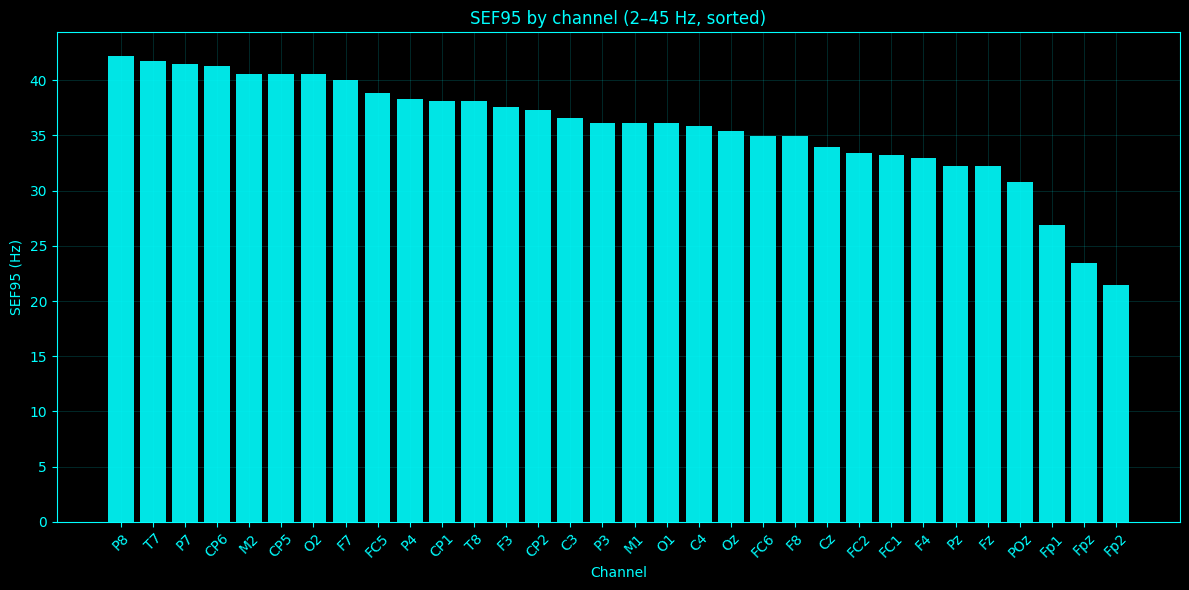

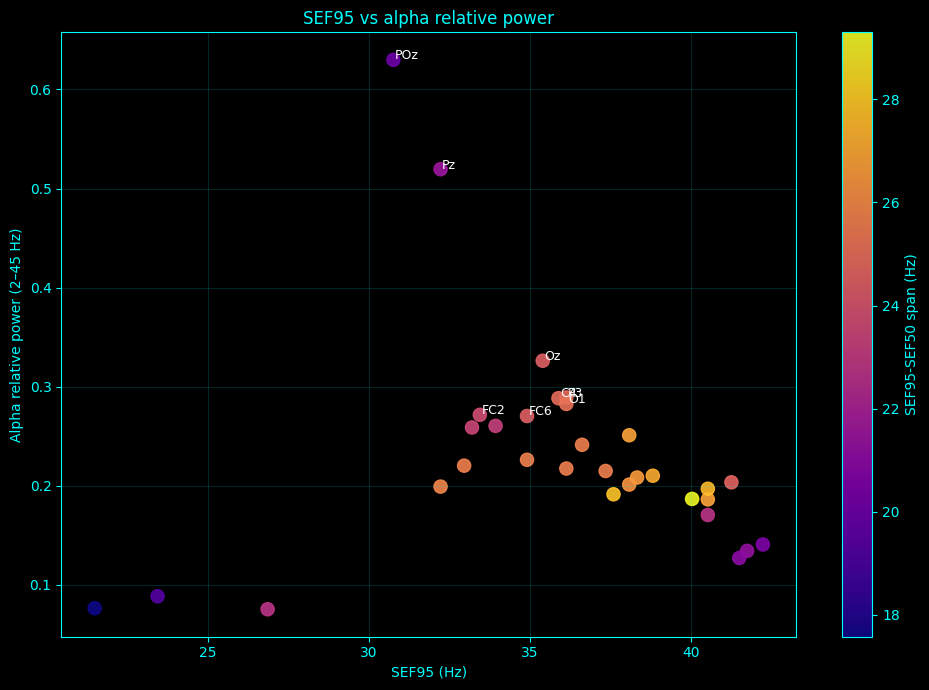

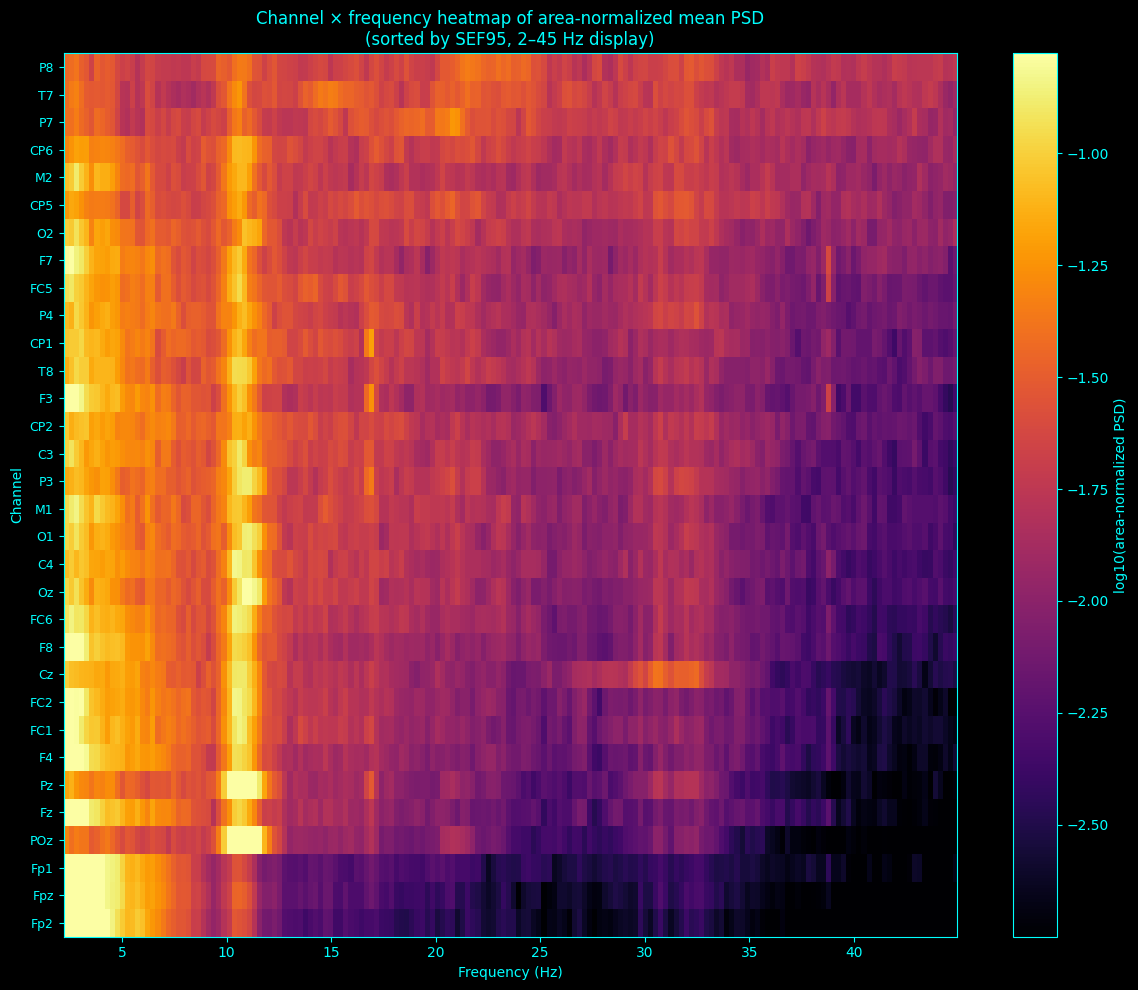

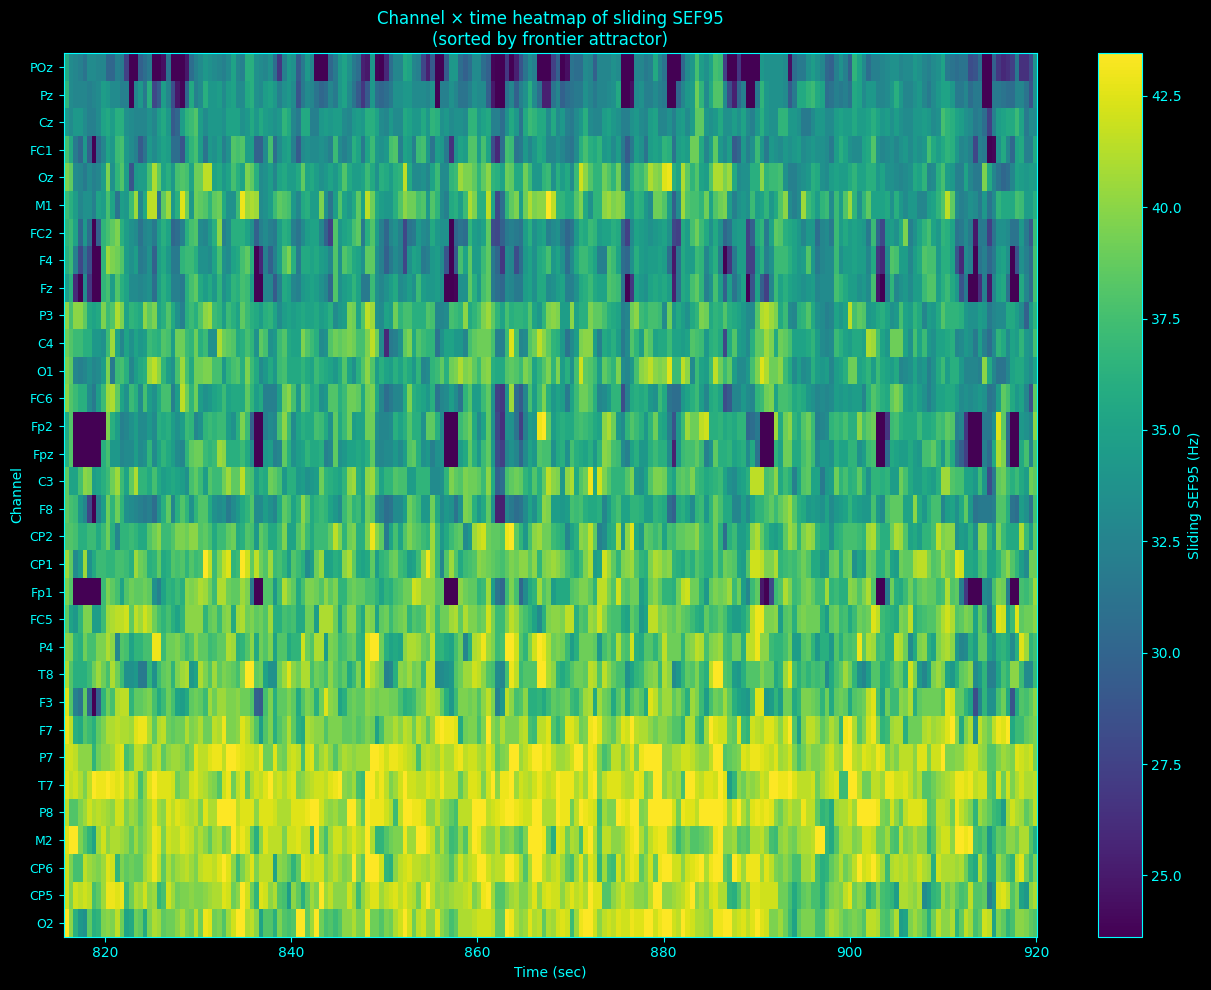

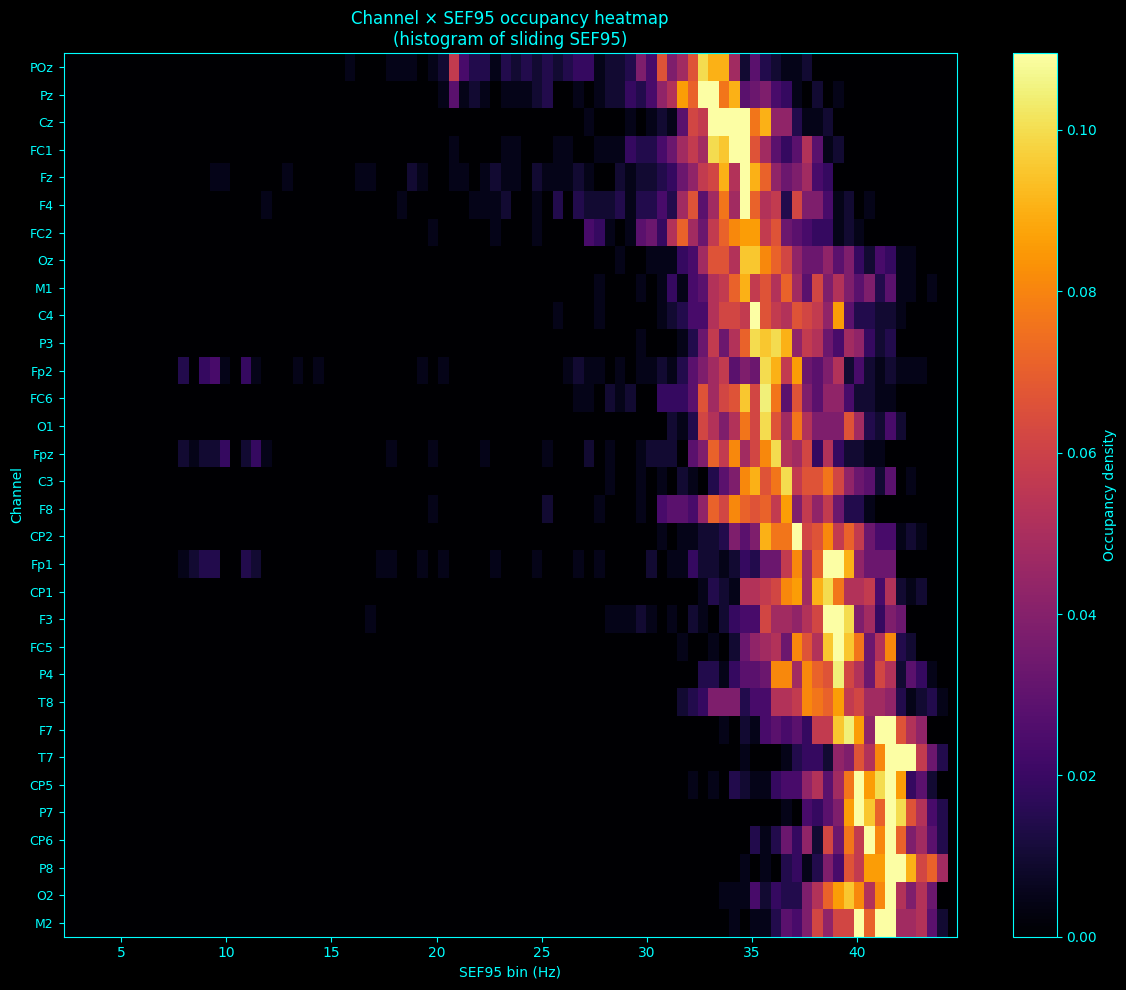

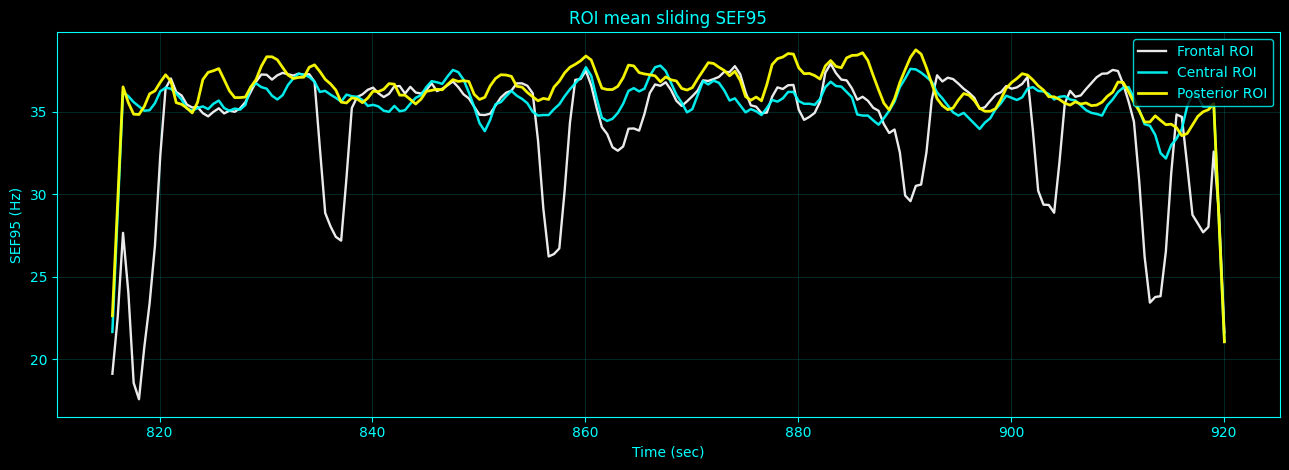

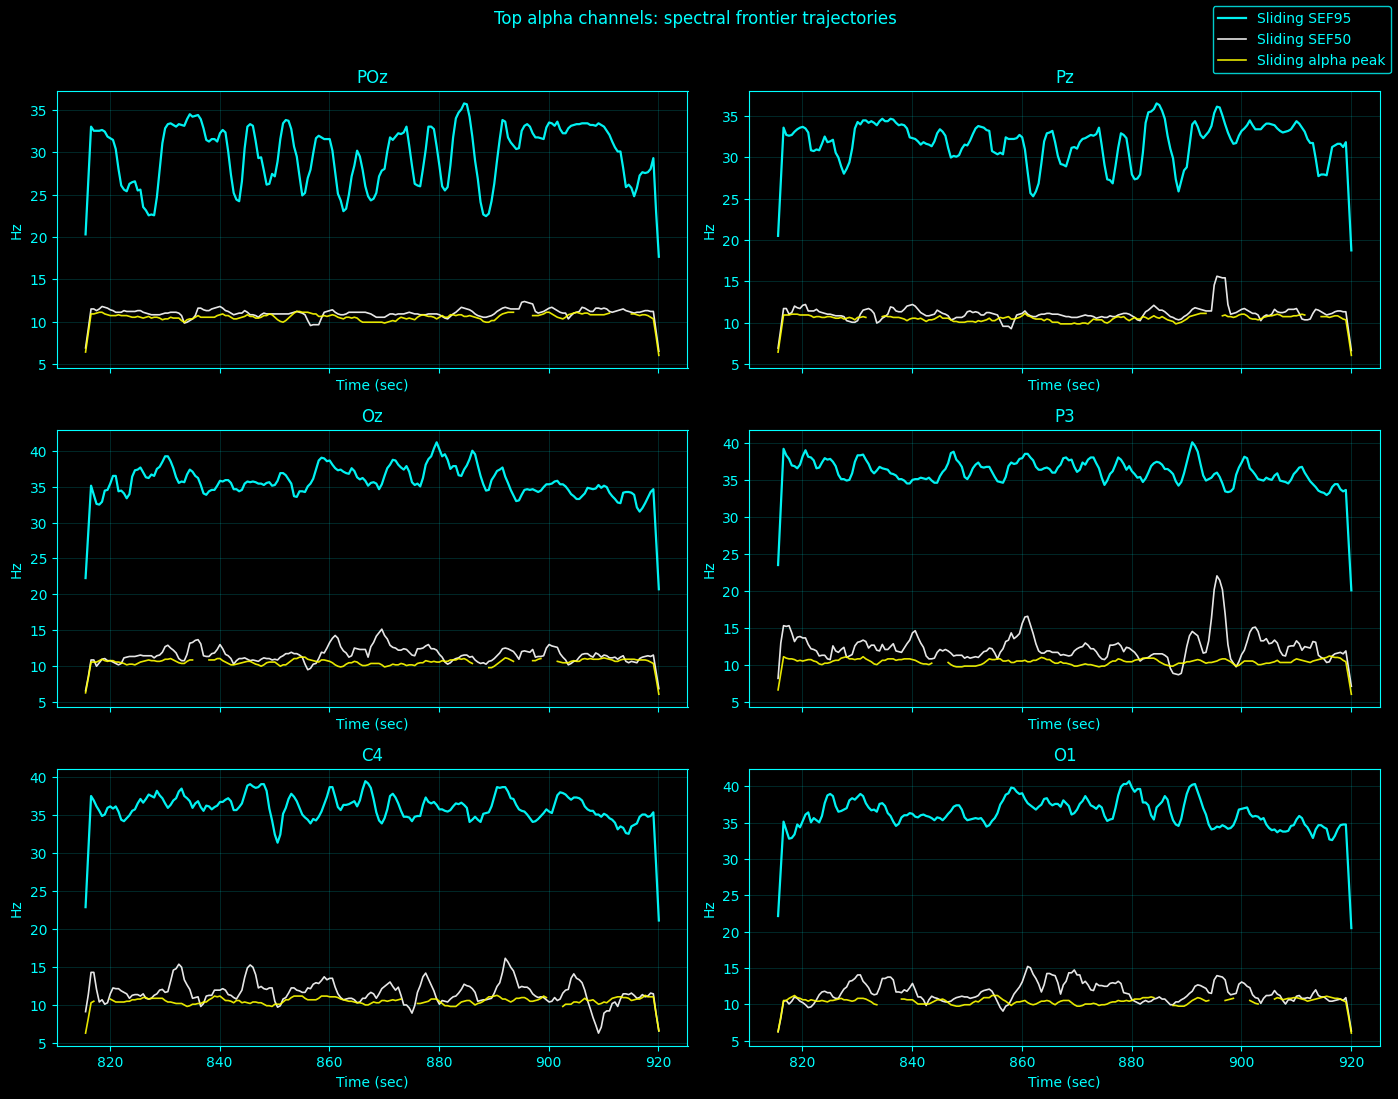


Saved dict NPY: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_edge_atlas/SpectralEdgeDensities_x.npy
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_edge_atlas/exploratory_spectral_edge_atlas_outputs.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_edge_atlas/spectral_edge_channel_summary.csv
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_edge_atlas/exploratory_spectral_edge_atlas_notes.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_edge_atlas/plots
Done.


In [1]:

# ---- Shared runtime mode (full preserves this cell's original settings) ----
FAST_OPTION = globals().get("FAST_OPTION", "full")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: full, balanced, fast, ultra")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, integrate

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — aligned to the upgraded scripts
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_spectral_edge_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

analysis_band = (2.0, 45.0)
display_band = (2.0, 45.0)
alpha_band = (8.0, 13.0)
theta_band = (4.0, 8.0)
beta_band = (13.0, 30.0)
delta_band = (2.0, 4.0)
low_gamma_band = (30.0, 45.0)

band_defs = {
    "delta": delta_band,
    "theta": theta_band,
    "alpha": alpha_band,
    "beta": beta_band,
    "low_gamma": low_gamma_band,
}

# Welch settings
welch_window_sec = 4.0
welch_overlap = 0.50
welch_nfft = 4096
detrend_mode = "constant"
apply_common_average_reference = False

# Sliding spectral-frontier settings
sliding_window_sec = 2.0
sliding_step_sec = {"full": 0.5, "balanced": 0.75, "fast": 1, "ultra": 1.5}[FAST_OPTION]
sliding_nfft = 2048

# Occupancy histogram for sliding SEF95
edge_hist_bin_width_hz = 0.5

# Canonical channel order used in the earlier scripts
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4'],
    "central":   ['C3', 'Cz', 'C4'],
    "posterior": ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2'],
}

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def band_mask(freqs_hz, band):
    lo, hi = band
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def welch_psd(y, fs, window_sec=4.0, overlap=0.5, detrend="constant", nfft=None):
    nperseg = min(int(round(window_sec * fs)), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = min(int(round(overlap * nperseg)), nperseg - 1)

    freqs_hz, pxx = signal.welch(
        y,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        scaling="density",
        nfft=nfft,
    )
    return freqs_hz, pxx

def area_normalize_1d(freqs_hz, x, band):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = band_mask(freqs_hz, band) & np.isfinite(x) & (x >= 0)
    if np.sum(mask) < 2:
        return out

    area = integrate_trapezoid(x[mask], freqs_hz[mask])
    if not np.isfinite(area) or area <= 0:
        return out

    out[mask] = x[mask] / area
    return out

def integrate_band_1d(freqs_hz, x, band):
    mask = band_mask(freqs_hz, band) & np.isfinite(x)
    if np.sum(mask) < 2:
        return np.nan
    return float(integrate_trapezoid(x[mask], freqs_hz[mask]))

def spectral_entropy_from_psd(freqs_hz, pxx, band=(2.0, 45.0), normalize=True):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)

    area = integrate_trapezoid(p, f)
    if not np.isfinite(area) or area <= 0:
        return np.nan, np.nan

    p = p / area
    p = p / (np.sum(p) + eps)

    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    Hn = H / (Hmax + eps) if normalize else H
    return float(H), float(Hn)

def spectral_centroid_from_psd(freqs_hz, pxx, band=(2.0, 45.0)):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan
    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)
    s = np.sum(p)
    if s <= 0:
        return np.nan
    return float(np.sum(f * p) / (s + eps))

def spectral_edge_frequency(freqs_hz, pxx, edge=0.95, band=(2.0, 45.0)):
    """
    Proper SEF:
    cumulative power across increasing frequency within the analysis band.
    """
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan

    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)

    cumulative = integrate.cumulative_trapezoid(p, f, initial=0.0)
    total = cumulative[-1]
    if not np.isfinite(total) or total <= 0:
        return np.nan

    target = edge * total
    idx = int(np.searchsorted(cumulative, target))
    idx = min(idx, len(f) - 1)
    return float(f[idx])

def robust_peak_in_band(freqs_hz, spectrum_1d, band=(7.0, 13.0), smooth_win=7):
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 5:
        return np.nan, np.nan, np.nan, np.nan

    f = freqs_hz[mask]
    y = smooth_1d(spectrum_1d[mask], win=smooth_win)

    peaks, _ = signal.find_peaks(y)
    if len(peaks) == 0:
        return np.nan, np.nan, np.nan, np.nan

    prominences = signal.peak_prominences(y, peaks)[0]
    valid = (peaks > 0) & (peaks < len(y) - 1)
    if not np.any(valid):
        return np.nan, np.nan, np.nan, np.nan

    peaks = peaks[valid]
    prominences = prominences[valid]

    min_prominence = max(0.05 * np.nanmax(y), 1.5 * np.nanmedian(np.abs(np.diff(y))))
    strong = prominences >= min_prominence
    if not np.any(strong):
        return np.nan, np.nan, np.nan, np.nan

    peaks = peaks[strong]
    prominences = prominences[strong]
    winner = int(np.argmax(prominences))
    peak_idx = peaks[winner]

    peak_freq = float(f[peak_idx])
    peak_height = float(y[peak_idx])
    peak_prominence = float(prominences[winner])
    peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
    return peak_freq, peak_height, peak_prominence, peak_contrast

def sliding_edge_dynamics(y, fs, analysis_band=(2.0, 45.0), alpha_band=(8.0, 13.0),
                          window_sec=2.0, step_sec=0.5, detrend="constant", nfft=2048):
    win = max(int(round(window_sec * fs)), 256)
    step = max(int(round(step_sec * fs)), 1)

    centers_sec = []
    sef50_series = []
    sef90_series = []
    sef95_series = []
    centroid_series = []
    entropy_series = []
    alpha_peak_series = []

    for start in range(0, len(y) - win + 1, step):
        stop = start + win
        chunk = y[start:stop]

        freqs_hz, pxx = welch_psd(
            chunk,
            fs=fs,
            window_sec=min(window_sec, len(chunk) / fs),
            overlap=0.5,
            detrend=detrend,
            nfft=nfft,
        )

        pxx_norm = area_normalize_1d(freqs_hz, pxx, analysis_band)

        sef50 = spectral_edge_frequency(freqs_hz, pxx, edge=0.50, band=analysis_band)
        sef90 = spectral_edge_frequency(freqs_hz, pxx, edge=0.90, band=analysis_band)
        sef95 = spectral_edge_frequency(freqs_hz, pxx, edge=0.95, band=analysis_band)
        centroid = spectral_centroid_from_psd(freqs_hz, pxx, band=analysis_band)
        _, Hn = spectral_entropy_from_psd(freqs_hz, pxx, band=analysis_band, normalize=True)
        alpha_peak, _, _, _ = robust_peak_in_band(freqs_hz, pxx_norm, band=alpha_band, smooth_win=7)

        centers_sec.append((start + stop) / 2.0 / fs)
        sef50_series.append(sef50)
        sef90_series.append(sef90)
        sef95_series.append(sef95)
        centroid_series.append(centroid)
        entropy_series.append(Hn)
        alpha_peak_series.append(alpha_peak)

    return {
        "time_sec_rel": np.asarray(centers_sec),
        "sef50_Hz": np.asarray(sef50_series),
        "sef90_Hz": np.asarray(sef90_series),
        "sef95_Hz": np.asarray(sef95_series),
        "spectral_centroid_Hz": np.asarray(centroid_series),
        "spectral_entropy_normalized": np.asarray(entropy_series),
        "alpha_peak_frequency_Hz": np.asarray(alpha_peak_series),
    }

def edge_histogram(edge_series_hz, band=(2.0, 45.0), bin_width_hz=0.5):
    valid = np.asarray(edge_series_hz, dtype=float)
    valid = valid[np.isfinite(valid)]
    valid = valid[(valid >= band[0]) & (valid <= band[1])]

    bins = np.arange(band[0], band[1] + bin_width_hz, bin_width_hz)
    if len(valid) == 0:
        hist = np.zeros(len(bins) - 1, dtype=float)
    else:
        hist, _ = np.histogram(valid, bins=bins)
        hist = hist.astype(float)
        hist = hist / (np.sum(hist) + eps)

    centers = 0.5 * (bins[:-1] + bins[1:])
    return centers, hist

def normalized_hist_entropy(hist):
    hist = np.asarray(hist, dtype=float)
    hist = hist[hist > 0]
    if len(hist) == 0:
        return np.nan
    H = -np.sum(hist * np.log(hist + eps))
    Hmax = np.log(len(hist) + eps)
    return float(H / (Hmax + eps))

def roi_average_matrix(matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.full(matrix.shape[0], np.nan)
    return np.nanmean(matrix[:, idx], axis=1)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Segment shape: {segment.shape}")

# -------------------------------------------------------
# CORE ANALYSIS
# -------------------------------------------------------
spectral_edge_dict = {}

summary_rows = []
mean_psd_matrix = []
sliding_sef50_matrix = []
sliding_sef90_matrix = []
sliding_sef95_matrix = []
sliding_centroid_matrix = []
sliding_entropy_matrix = []
sliding_alpha_peak_matrix = []
edge_hist_matrix = []

time_centers_ref = None
freqs_ref = None
edge_hist_centers_ref = None

for ch_i, ch_name in enumerate(eeg_channel_names):
    y = segment[:, ch_i]

    # Stationary PSD / frontier geometry
    freqs_hz, pxx = welch_psd(
        y,
        fs=sampling_rate,
        window_sec=welch_window_sec,
        overlap=welch_overlap,
        detrend=detrend_mode,
        nfft=welch_nfft,
    )

    if freqs_ref is None:
        freqs_ref = freqs_hz

    mean_psd_norm = area_normalize_1d(freqs_hz, pxx, analysis_band)

    sef50 = spectral_edge_frequency(freqs_hz, pxx, edge=0.50, band=analysis_band)
    sef90 = spectral_edge_frequency(freqs_hz, pxx, edge=0.90, band=analysis_band)
    sef95 = spectral_edge_frequency(freqs_hz, pxx, edge=0.95, band=analysis_band)

    edge_span_50_95 = sef95 - sef50 if np.isfinite(sef95) and np.isfinite(sef50) else np.nan
    edge_span_90_95 = sef95 - sef90 if np.isfinite(sef95) and np.isfinite(sef90) else np.nan

    centroid_hz = spectral_centroid_from_psd(freqs_hz, pxx, band=analysis_band)
    _, entropy_norm = spectral_entropy_from_psd(freqs_hz, pxx, band=analysis_band, normalize=True)

    alpha_peak_hz, alpha_peak_height, alpha_peak_prominence, alpha_peak_contrast = robust_peak_in_band(
        freqs_hz,
        mean_psd_norm,
        band=alpha_band,
        smooth_win=7,
    )

    alpha_rel = integrate_band_1d(freqs_hz, mean_psd_norm, alpha_band)
    theta_rel = integrate_band_1d(freqs_hz, mean_psd_norm, theta_band)
    beta_rel = integrate_band_1d(freqs_hz, mean_psd_norm, beta_band)
    delta_rel = integrate_band_1d(freqs_hz, mean_psd_norm, delta_band)
    low_gamma_rel = integrate_band_1d(freqs_hz, mean_psd_norm, low_gamma_band)

    # Novel exploratory frontier descriptors
    frontier_alpha_gap = (
        sef50 - alpha_peak_hz
        if np.isfinite(sef50) and np.isfinite(alpha_peak_hz)
        else np.nan
    )
    frontier_centroid_gap = (
        sef95 - centroid_hz
        if np.isfinite(sef95) and np.isfinite(centroid_hz)
        else np.nan
    )

    # Sliding edge dynamics
    sliding = sliding_edge_dynamics(
        y,
        fs=sampling_rate,
        analysis_band=analysis_band,
        alpha_band=alpha_band,
        window_sec=sliding_window_sec,
        step_sec=sliding_step_sec,
        detrend=detrend_mode,
        nfft=sliding_nfft,
    )

    if time_centers_ref is None:
        time_centers_ref = sliding["time_sec_rel"]

    hist_centers, hist_density = edge_histogram(
        sliding["sef95_Hz"],
        band=analysis_band,
        bin_width_hz=edge_hist_bin_width_hz,
    )
    if edge_hist_centers_ref is None:
        edge_hist_centers_ref = hist_centers

    attractor_edge_hz = float(hist_centers[np.argmax(hist_density)]) if np.any(np.isfinite(hist_density)) else np.nan
    attractor_entropy = normalized_hist_entropy(hist_density)

    valid_sef95 = sliding["sef95_Hz"][np.isfinite(sliding["sef95_Hz"])]
    if len(valid_sef95) > 0:
        sef95_std = float(np.nanstd(valid_sef95))
        sef95_range = float(np.nanmax(valid_sef95) - np.nanmin(valid_sef95))
        sef95_median = float(np.nanmedian(valid_sef95))
    else:
        sef95_std = np.nan
        sef95_range = np.nan
        sef95_median = np.nan

    if np.sum(np.isfinite(sliding["sef95_Hz"])) > 1:
        sef95_jump_mean = float(np.nanmean(np.abs(np.diff(sliding["sef95_Hz"]))))
    else:
        sef95_jump_mean = np.nan

    if np.nanstd(sliding["sef95_Hz"]) > 0 and np.nanstd(sliding["spectral_entropy_normalized"]) > 0:
        frontier_entropy_coupling = float(np.corrcoef(sliding["sef95_Hz"], sliding["spectral_entropy_normalized"])[0, 1])
    else:
        frontier_entropy_coupling = np.nan

    if np.nanstd(sliding["sef95_Hz"]) > 0 and np.nanstd(sliding["spectral_centroid_Hz"]) > 0:
        frontier_centroid_coupling = float(np.corrcoef(sliding["sef95_Hz"], sliding["spectral_centroid_Hz"])[0, 1])
    else:
        frontier_centroid_coupling = np.nan

    frontier_alpha_gap_series = sliding["sef50_Hz"] - sliding["alpha_peak_frequency_Hz"]
    frontier_alpha_gap_mean = float(np.nanmean(frontier_alpha_gap_series))
    frontier_alpha_gap_std = float(np.nanstd(frontier_alpha_gap_series))

    stationary_vs_attractor_mismatch = (
        sef95 - attractor_edge_hz
        if np.isfinite(sef95) and np.isfinite(attractor_edge_hz)
        else np.nan
    )

    spectral_edge_dict[ch_name] = {
        "sef50_Hz": sef50,
        "sef90_Hz": sef90,
        "sef95_Hz": sef95,
        "edge_span_50_95_Hz": edge_span_50_95,
        "edge_span_90_95_Hz": edge_span_90_95,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "spectral_centroid_Hz_2_45Hz": centroid_hz,
        "spectral_entropy_normalized_2_45Hz": entropy_norm,
        "frontier_alpha_gap_Hz": frontier_alpha_gap,
        "frontier_centroid_gap_Hz": frontier_centroid_gap,
        "sliding_sef50_Hz": sliding["sef50_Hz"],
        "sliding_sef90_Hz": sliding["sef90_Hz"],
        "sliding_sef95_Hz": sliding["sef95_Hz"],
        "sliding_spectral_centroid_Hz": sliding["spectral_centroid_Hz"],
        "sliding_spectral_entropy_normalized": sliding["spectral_entropy_normalized"],
        "sliding_alpha_peak_frequency_Hz": sliding["alpha_peak_frequency_Hz"],
        "edge_hist_centers_Hz": hist_centers,
        "edge_hist_density": hist_density,
        "attractor_edge_Hz": attractor_edge_hz,
        "attractor_entropy": attractor_entropy,
        "frequencies_hz": freqs_hz,
        "mean_psd_area_norm_2_45Hz": mean_psd_norm,
        "time_sec_rel": sliding["time_sec_rel"],
    }

    summary_rows.append({
        "channel": ch_name,
        "sef50_Hz_2_45Hz": sef50,
        "sef90_Hz_2_45Hz": sef90,
        "sef95_Hz_2_45Hz": sef95,
        "edge_span_50_95_Hz": edge_span_50_95,
        "edge_span_90_95_Hz": edge_span_90_95,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "alpha_peak_height_area_norm": alpha_peak_height,
        "alpha_peak_prominence": alpha_peak_prominence,
        "alpha_peak_contrast": alpha_peak_contrast,
        "alpha_relative_power_2_45Hz": alpha_rel,
        "theta_relative_power_2_45Hz": theta_rel,
        "beta_relative_power_2_45Hz": beta_rel,
        "delta_relative_power_2_45Hz": delta_rel,
        "low_gamma_relative_power_2_45Hz": low_gamma_rel,
        "spectral_centroid_Hz_2_45Hz": centroid_hz,
        "spectral_entropy_normalized_2_45Hz": entropy_norm,
        "frontier_alpha_gap_Hz": frontier_alpha_gap,
        "frontier_centroid_gap_Hz": frontier_centroid_gap,
        "sliding_sef95_median_Hz": sef95_median,
        "sliding_sef95_std_Hz": sef95_std,
        "sliding_sef95_range_Hz": sef95_range,
        "sliding_sef95_jump_mean_Hz": sef95_jump_mean,
        "frontier_entropy_coupling": frontier_entropy_coupling,
        "frontier_centroid_coupling": frontier_centroid_coupling,
        "frontier_alpha_gap_mean_Hz": frontier_alpha_gap_mean,
        "frontier_alpha_gap_std_Hz": frontier_alpha_gap_std,
        "attractor_edge_Hz": attractor_edge_hz,
        "attractor_entropy": attractor_entropy,
        "stationary_vs_attractor_mismatch_Hz": stationary_vs_attractor_mismatch,
    })

    mean_psd_matrix.append(mean_psd_norm)
    sliding_sef50_matrix.append(sliding["sef50_Hz"])
    sliding_sef90_matrix.append(sliding["sef90_Hz"])
    sliding_sef95_matrix.append(sliding["sef95_Hz"])
    sliding_centroid_matrix.append(sliding["spectral_centroid_Hz"])
    sliding_entropy_matrix.append(sliding["spectral_entropy_normalized"])
    sliding_alpha_peak_matrix.append(sliding["alpha_peak_frequency_Hz"])
    edge_hist_matrix.append(hist_density)

summary_df = pd.DataFrame(summary_rows)
for col in summary_df.columns:
    if col != "channel":
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

mean_psd_matrix = np.column_stack(mean_psd_matrix)
sliding_sef50_matrix = np.column_stack(sliding_sef50_matrix)
sliding_sef90_matrix = np.column_stack(sliding_sef90_matrix)
sliding_sef95_matrix = np.column_stack(sliding_sef95_matrix)
sliding_centroid_matrix = np.column_stack(sliding_centroid_matrix)
sliding_entropy_matrix = np.column_stack(sliding_entropy_matrix)
sliding_alpha_peak_matrix = np.column_stack(sliding_alpha_peak_matrix)
edge_hist_matrix = np.column_stack(edge_hist_matrix)
time_sec_abs = start_time + time_centers_ref

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
dict_npy_path = os.path.join(out_dir, "SpectralEdgeDensities_x.npy")
npz_path = os.path.join(out_dir, "exploratory_spectral_edge_atlas_outputs.npz")
summary_csv_path = os.path.join(out_dir, "spectral_edge_channel_summary.csv")
notes_txt_path = os.path.join(out_dir, "exploratory_spectral_edge_atlas_notes.txt")

np.save(dict_npy_path, spectral_edge_dict, allow_pickle=True)

np.savez_compressed(
    npz_path,
    frequencies_hz=freqs_ref,
    time_sec_abs=time_sec_abs,
    time_sec_rel=time_centers_ref,
    edge_hist_centers_Hz=edge_hist_centers_ref,
    mean_psd_area_norm_2_45Hz=mean_psd_matrix,
    sliding_sef50_Hz=sliding_sef50_matrix,
    sliding_sef90_Hz=sliding_sef90_matrix,
    sliding_sef95_Hz=sliding_sef95_matrix,
    sliding_spectral_centroid_Hz=sliding_centroid_matrix,
    sliding_spectral_entropy_normalized=sliding_entropy_matrix,
    sliding_alpha_peak_frequency_Hz=sliding_alpha_peak_matrix,
    edge_hist_density=edge_hist_matrix,
    channel_names=np.array(eeg_channel_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
    analysis_band=np.array(analysis_band, dtype=float),
    welch_window_sec=welch_window_sec,
    sliding_window_sec=sliding_window_sec,
    sliding_step_sec=sliding_step_sec,
)

summary_df.to_csv(summary_csv_path, index=False)

top_sef95 = summary_df.sort_values("sef95_Hz_2_45Hz", ascending=False).head(8)
low_sef95 = summary_df.sort_values("sef95_Hz_2_45Hz", ascending=True).head(8)
top_alpha = summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(8)
top_stable = summary_df.sort_values("sliding_sef95_std_Hz", ascending=True).head(8)
top_unstable = summary_df.sort_values("sliding_sef95_std_Hz", ascending=False).head(8)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory spectral edge atlas notes\n")
    f.write("=====================================\n\n")
    f.write("Intent:\n")
    f.write("This pass treats spectral edge as a dynamic spectral-frontier problem rather than a raw FFT magnitude trick.\n")
    f.write("It is for exploratory expert research, not publishing, not benchmarking, and not scoring.\n\n")
    f.write("Why the original version failed:\n")
    f.write("1. It sorted magnitudes instead of integrating power across increasing frequency.\n")
    f.write("2. It used raw FFT magnitude rather than a stable PSD estimate.\n")
    f.write("3. It ignored the selected segment of interest and physiological band control.\n\n")
    f.write("What this version adds:\n")
    f.write("1. Proper one-sided Welch PSD.\n")
    f.write("2. Proper SEF50 / SEF90 / SEF95 in 2–45 Hz.\n")
    f.write("3. Frontier geometry: edge spans, alpha anchoring, centroid gap.\n")
    f.write("4. Sliding SEF dynamics over time.\n")
    f.write("5. Frontier occupancy histograms and attractor entropy.\n")
    f.write("6. Novel exploratory descriptors: frontier mobility, frontier-entropy coupling, frontier-alpha gap stability,\n")
    f.write("   and stationary-vs-attractor mismatch.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Analysis band: [{analysis_band[0]:.1f}, {analysis_band[1]:.1f}] Hz\n")
    f.write(f"Welch window: {welch_window_sec:.2f} sec\n")
    f.write(f"Sliding window: {sliding_window_sec:.2f} sec\n")
    f.write(f"Sliding step: {sliding_step_sec:.2f} sec\n")
    f.write(f"Common average reference applied: {apply_common_average_reference}\n\n")

    f.write("Highest SEF95 channels:\n")
    for _, row in top_sef95.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"SEF95={row['sef95_Hz_2_45Hz']:.3f} Hz, "
            f"SEF50={row['sef50_Hz_2_45Hz']:.3f} Hz, "
            f"edge_span={row['edge_span_50_95_Hz']:.3f} Hz, "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}\n"
        )

    f.write("\nLowest SEF95 channels:\n")
    for _, row in low_sef95.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"SEF95={row['sef95_Hz_2_45Hz']:.3f} Hz, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']}, "
            f"frontier_alpha_gap={row['frontier_alpha_gap_Hz']}\n"
        )

    f.write("\nTop alpha-relative-power channels:\n")
    for _, row in top_alpha.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']:.3f} Hz, "
            f"SEF50={row['sef50_Hz_2_45Hz']:.3f} Hz\n"
        )

    f.write("\nMost stable sliding-SEF95 channels:\n")
    for _, row in top_stable.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"SEF95 std={row['sliding_sef95_std_Hz']:.3f} Hz, "
            f"attractor_entropy={row['attractor_entropy']:.3f}, "
            f"frontier_entropy_coupling={row['frontier_entropy_coupling']}\n"
        )

    f.write("\nMost unstable sliding-SEF95 channels:\n")
    for _, row in top_unstable.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"SEF95 std={row['sliding_sef95_std_Hz']:.3f} Hz, "
            f"SEF95 jump mean={row['sliding_sef95_jump_mean_Hz']:.3f} Hz, "
            f"stationary-vs-attractor mismatch={row['stationary_vs_attractor_mismatch_Hz']}\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Bar plot of SEF95 sorted by SEF95
sort_df = summary_df.sort_values("sef95_Hz_2_45Hz", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)
ax.bar(sort_df["channel"], sort_df["sef95_Hz_2_45Hz"], color=ACCENT, alpha=0.9)
ax.set_title("SEF95 by channel (2–45 Hz, sorted)")
ax.set_xlabel("Channel")
ax.set_ylabel("SEF95 (Hz)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "01_sef95_bar_sorted.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Descriptor space: SEF95 vs alpha relative power
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)
scatter = ax.scatter(
    summary_df["sef95_Hz_2_45Hz"].values,
    summary_df["alpha_relative_power_2_45Hz"].values,
    c=summary_df["edge_span_50_95_Hz"].values,
    s=90,
    alpha=0.9,
    cmap="plasma",
)

annotate_df = summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(8)
for _, row in annotate_df.iterrows():
    ax.text(
        row["sef95_Hz_2_45Hz"] + 0.05,
        row["alpha_relative_power_2_45Hz"] + 0.0007,
        row["channel"],
        color="white",
        fontsize=9,
    )

ax.set_title("SEF95 vs alpha relative power")
ax.set_xlabel("SEF95 (Hz)")
ax.set_ylabel("Alpha relative power (2–45 Hz)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("SEF95-SEF50 span (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "02_sef95_vs_alpha_descriptor_space.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Channel × frequency heatmap of mean PSD, sorted by SEF95
sorted_channels = list(sort_df["channel"].values)
sorted_idx = [eeg_channel_names.index(ch) for ch in sorted_channels]
display_mask = band_mask(freqs_ref, display_band)
freqs_display = freqs_ref[display_mask]

heat = np.log10(mean_psd_matrix[display_mask][:, sorted_idx].T + 1e-6)
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[freqs_display[0], freqs_display[-1], len(sorted_channels), 0],
)
ax.set_title("Channel × frequency heatmap of area-normalized mean PSD\n(sorted by SEF95, 2–45 Hz display)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(area-normalized PSD)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "03_channel_frequency_heatmap_sef_sorted.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Channel × time heatmap of sliding SEF95
dyn_sort_df = summary_df.sort_values(
    by=["attractor_edge_Hz", "sliding_sef95_std_Hz"],
    ascending=[True, True],
).reset_index(drop=True)
dyn_sorted_channels = list(dyn_sort_df["channel"].values)
dyn_sorted_idx = [eeg_channel_names.index(ch) for ch in dyn_sorted_channels]

sliding_heat = sliding_sef95_matrix[:, dyn_sorted_idx].T
vmin, vmax = percentile_limits(sliding_heat, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    sliding_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    extent=[time_sec_abs[0], time_sec_abs[-1], len(dyn_sorted_channels), 0],
)
ax.set_title("Channel × time heatmap of sliding SEF95\n(sorted by frontier attractor)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(dyn_sorted_channels)) + 0.5)
ax.set_yticklabels(dyn_sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Sliding SEF95 (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "04_sliding_sef95_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Channel × SEF95 occupancy heatmap
edge_sort_df = summary_df.sort_values(
    by=["attractor_edge_Hz", "attractor_entropy"],
    ascending=[True, True],
).reset_index(drop=True)
edge_sorted_channels = list(edge_sort_df["channel"].values)
edge_sorted_idx = [eeg_channel_names.index(ch) for ch in edge_sorted_channels]

heat = edge_hist_matrix[:, edge_sorted_idx].T
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[edge_hist_centers_ref[0], edge_hist_centers_ref[-1], len(edge_sorted_channels), 0],
)
ax.set_title("Channel × SEF95 occupancy heatmap\n(histogram of sliding SEF95)")
ax.set_xlabel("SEF95 bin (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(edge_sorted_channels)) + 0.5)
ax.set_yticklabels(edge_sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Occupancy density", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "05_sef95_occupancy_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) ROI mean sliding SEF95
frontal_sef95 = roi_average_matrix(sliding_sef95_matrix, eeg_channel_names, roi_definitions["frontal"])
central_sef95 = roi_average_matrix(sliding_sef95_matrix, eeg_channel_names, roi_definitions["central"])
posterior_sef95 = roi_average_matrix(sliding_sef95_matrix, eeg_channel_names, roi_definitions["posterior"])

fig, ax = plt.subplots(figsize=(13, 4.8), facecolor=BG)
style_ax(ax)
ax.plot(time_sec_abs, smooth_1d(frontal_sef95, win=5), color="white", linewidth=1.7, alpha=0.92, label="Frontal ROI")
ax.plot(time_sec_abs, smooth_1d(central_sef95, win=5), color=ACCENT, linewidth=1.8, alpha=0.92, label="Central ROI")
ax.plot(time_sec_abs, smooth_1d(posterior_sef95, win=5), color="yellow", linewidth=2.0, alpha=0.95, label="Posterior ROI")
ax.set_title("ROI mean sliding SEF95")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("SEF95 (Hz)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "06_roi_mean_sliding_sef95.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 7) Top alpha channels: SEF95, SEF50, and alpha peak trajectories
top_alpha_channels = list(summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(6)["channel"].values)

fig, axes = plt.subplots(3, 2, figsize=(14, 11), facecolor=BG, sharex=True, sharey=False)
axes = np.asarray(axes).ravel()

for ax, ch_name in zip(axes, top_alpha_channels):
    style_ax(ax)
    ch_idx = eeg_channel_names.index(ch_name)

    sef95_series = smooth_1d(sliding_sef95_matrix[:, ch_idx], win=5)
    sef50_series = smooth_1d(sliding_sef50_matrix[:, ch_idx], win=5)
    alpha_series = smooth_1d(sliding_alpha_peak_matrix[:, ch_idx], win=5)

    ax.plot(time_sec_abs, sef95_series, color=ACCENT, linewidth=1.6, alpha=0.95, label="Sliding SEF95")
    ax.plot(time_sec_abs, sef50_series, color="white", linewidth=1.2, alpha=0.9, label="Sliding SEF50")
    ax.plot(time_sec_abs, alpha_series, color="yellow", linewidth=1.2, alpha=0.9, label="Sliding alpha peak")
    ax.set_title(ch_name)
    ax.set_xlabel("Time (sec)")
    ax.set_ylabel("Hz")

for ax in axes[len(top_alpha_channels):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Top alpha channels: spectral frontier trajectories", color=ACCENT, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig(os.path.join(plots_dir, "07_top_alpha_channels_frontier_trajectories.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved dict NPY: {dict_npy_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plots to: {plots_dir}")
print("Done.")

# Continuous Wavelet Transform

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This code focuses on extracting wavelet coefficients from EEG data across multiple channels. It uses Continuous Wavelet Transform (CWT) for time-frequency analysis. The aim is to identify time-locked events and analyze localized frequency content of the EEG signals.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <p>The Continuous Wavelet Transform is used to analyze signals in both the time and frequency domains simultaneously. The wavelet is a small wave that is used to analyze localized variations in a signal. In this code, the 'morl' (Morlet) wavelet is used for transformation.</p>
        \[
        CWT_{x}(a, b) = \frac{1}{\sqrt{|a|}} \int x(t)\psi \left( \frac{t-b}{a} \right) dt
        \]
        <p>Where \( \psi \) is the wavelet function, \( a \) is the scaling parameter, and \( b \) is the translation parameter.</p>
        <p>The CWT is calculated at logarithmically spaced frequencies, making it suitable for analyzing signals that contain components at multiple scales.</p>
        <p>Each channel's wavelet coefficients are stored in a dictionary, <code>wavelet_coefficients</code>, and the coefficients are also visualized using a heatmap. This enables easy comparison between channels and provides a sense of how the frequency content changes over time.</p>
        <p>The wavelet coefficients are saved as a numpy array for subsequent analyses. The output is saved to the directory specified in the <code>results_path</code> and <code>results_file</code> variables.</p>
    </div>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A wavelet transform compares the signal with short oscillatory templates that are shifted in time and stretched or compressed in scale. Small scales correspond roughly to faster oscillations and large scales to slower ones, with the exact scale-frequency conversion depending on the chosen wavelet. This produces a time-frequency representation, which is useful when EEG spectral content changes over time. Near the beginning and end of the recording, estimates are less reliable because the wavelet extends beyond the available data.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>
